# 03MIAR Algoritmos de Optimización - Proyecto de Programación

* **Link a Google Colab:** [Acceder al Cuaderno Interactivo](https://colab.research.google.com/drive/11W-_g0Lxe2WVPMy7k-gmWZec1ihwvdIJ?usp=sharing)
* **Repositorio GitHub:** [Ver Código Fuente](https://github.com/marlev88/AlgoritmosOptimizacion/tree/main/Proyecto_Algoritmos)

**Nombre y apellidos:**  

- Carlos Martinez Arevalo
- Marcos Antonio Lévano Huamaccto

**Numero de Grupo:** 49  
**Asignatura:** Algoritmos de Optimización  
**Problema seleccionado:** Problema 1 — Organizar sesiones de doblaje

## Problema 

1) Organizar sesiones de doblaje

Se precisa coordinar el doblaje de una película. Los actores del doblaje deben coincidir en las
tomas en las que sus personajes aparecen juntos en las diferentes tomas. Los actores de
doblaje cobran todos la misma cantidad por cada día que deben desplazarse hasta el estudio de
grabación independientemente del número de tomas que se graben. No es posible grabar más
de 6 tomas por día. El objetivo es planificar las sesiones por día de manera que el gasto por los
servicios de los actores de doblaje sea el menor posible. Los datos son se pueden ver en el link del enunciado [2]:

- Número de actores: 10
- Número de tomas : 30
- Actores/Tomas : https://bit.ly/36D8IuK  
1 indica que el actor participa en la toma  
0 en caso contrario

El objetivo consiste en organizar las tomas de manera que se minimice el número total de asistencias diarias de los actores.

## Parte I. Análisis general del problema

En esta parte se responden las preguntas generales del enunciado. Estas respuestas describen el problema y serán válidas para las diferentes técnicas de optimización que se implementen posteriormente. Llevando a cabo el modelado, diseño y análisis.


### Pregunta 1 (*)

**¿Cuántas posibilidades hay sin tener en cuenta las restricciones?**

Sin considerar las restricciones del problema, se asume que cada una de las 30 tomas puede asignarse de forma independiente a cualquiera de los 5 días de grabación. Por tanto, cada toma tiene cinco posibles asignaciones y el número total de planificaciones posibles se obtiene mediante el principio multiplicativo:

$$5^{30}=931322574615478515625$$

aproximadamente,

$$9.31×10^{20}$$

posibles asignaciones.

Este resultado incluye tanto planificaciones válidas como inválidas, ya que no se considera la restricción de que en un mismo día no pueden grabarse más de seis tomas. Por ejemplo, se permiten situaciones en las que todas las tomas se asignan al mismo día o en las que algunos días quedan sin actividad. El enorme tamaño del espacio de búsqueda evidencia que una búsqueda exhaustiva resulta computacionalmente inviable, justificando el uso de técnicas de optimización como la Programación Lineal Entera Binaria y las metaheurísticas.

In [1]:
NUM_TOMAS_PROBLEMA = 30
NUM_DIAS_PROBLEMA = 5

posibilidades_sin_restricciones = (
    NUM_DIAS_PROBLEMA ** NUM_TOMAS_PROBLEMA
)

print(
    f"{NUM_DIAS_PROBLEMA}^{NUM_TOMAS_PROBLEMA} =",
    posibilidades_sin_restricciones
)
print(
    "Notación científica:",
    f"{posibilidades_sin_restricciones:.3e}"
)


5^30 = 931322574615478515625
Notación científica: 9.313e+20


### Pregunta 2

**¿Cuántas posibilidades hay teniendo en cuenta todas las restricciones?**

Al imponer que no pueden grabarse más de 6 tomas por día y disponer de 5 días para organizar las 30 tomas, necesariamente deben asignarse exactamente 6 tomas a cada jornada.

Si los días están identificados como Día 1, Día 2, ..., Día 5 y el orden interno de las tomas dentro de una misma jornada no importa, el número de planificaciones válidas es:

$$
\boxed{\frac{30!}{(6!)^5}}
$$

Esta es la respuesta principal para el problema, porque las jornadas están identificadas.

De manera complementaria, si solo interesaran los cinco grupos de tomas y se considerara equivalente intercambiar días completos, habría que dividir también por \(5!\):

$$
\frac{30!}{(6!)^5\,5!}
$$

En los algoritmos se representa una solución mediante una permutación de las 30 tomas dividida en cinco bloques consecutivos de seis. Esta codificación es sencilla, pero presenta redundancia: distintas permutaciones pueden representar la misma planificación.

In [2]:
import math

posibilidades_dias_identificados = (
    math.factorial(30) // (math.factorial(6) ** 5)
)

posibilidades_dias_equivalentes = (
    math.factorial(30)
    // ((math.factorial(6) ** 5) * math.factorial(5))
)

print("Planificaciones con días identificados:", posibilidades_dias_identificados)
print("Particiones considerando días equivalentes:", posibilidades_dias_equivalentes)


Planificaciones con días identificados: 1370874167589326400
Particiones considerando días equivalentes: 11423951396577720


### Pregunta 3 (*)

**¿Cuál es la estructura de datos que mejor se adapta al problema?**

Los datos de participación se representan mediante una **matriz binaria de tamaño \(30 \times 10\)**:

- cada fila representa una toma;
- cada columna representa un actor;
- el valor 1 indica que el actor participa en la toma;
- el valor 0 indica que no participa.

Una planificación se representa mediante una **lista o permutación de los índices de las 30 tomas**. La lista se divide en cinco bloques consecutivos de seis elementos, donde cada bloque representa un día de grabación.

Esta estructura resulta adecuada porque garantiza que cada toma aparezca una sola vez, permite respetar fácilmente el límite de seis tomas por día y facilita la aplicación de operadores propios de las técnicas de optimización, como intercambio, inversión, cruce y mutación.


### Pregunta 4 (*)

**¿Cuál es la función objetivo?**

La función objetivo calcula el número total de asistencias de los actores a lo largo de todos los días:

$$
f(S)=\sum_{d=1}^{5}\sum_{a=1}^{10} y_{a,d}
$$

donde $y_{a,d}=1$ cuando el actor $a$ participa en al menos una toma programada para el día $d$, y $y_{a,d}=0$ en caso contrario.

Un actor se contabiliza una sola vez por día, aunque participe en varias tomas de esa misma jornada.


### Pregunta 5 (*)

**¿Es un problema de maximización o minimización?**

Es un problema de **minimización**, porque se busca reducir el costo total asociado a los desplazamientos diarios de los actores. Una solución será mejor que otra cuando produzca un menor número total de asistencias actor-día.


## Parte II. Preparación común para los algoritmos

Las siguientes celdas cargan los datos y definen las funciones que se reutilizarán en fuerza bruta, búsqueda aleatoria, búsqueda local, recocido simulado, colonia de hormigas y algoritmo genético.


### Carga y validación de los datos


In [3]:
from pathlib import Path
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RUTA_DATOS = Path("actores_tomas.csv")

if not RUTA_DATOS.exists():
    raise FileNotFoundError(
        f"No se encontró el archivo '{RUTA_DATOS}'. "
        "Colócalo en la misma carpeta que el notebook."
    )

# utf-8-sig elimina el carácter BOM que puede aparecer al exportar desde Excel.
df = pd.read_csv(
    RUTA_DATOS,
    sep=None,
    engine="python",
    encoding="utf-8-sig"
)

# Limpiar espacios y posibles caracteres ocultos en los encabezados.
df.columns = (
    df.columns
      .astype(str)
      .str.replace("\ufeff", "", regex=False)
      .str.strip()
)

if "Toma" not in df.columns:
    raise ValueError(
        "El archivo debe contener una columna llamada 'Toma'. "
        f"Columnas encontradas: {list(df.columns)}"
    )

df_actores = df.drop(columns=["Toma"]).astype(int)

if not df_actores.isin([0, 1]).all().all():
    raise ValueError("Las columnas de actores solo deben contener valores 0 y 1.")

A = df_actores.to_numpy()

NUM_TOMAS, NUM_ACTORES = A.shape
TOMAS_POR_DIA = 6

if NUM_TOMAS % TOMAS_POR_DIA != 0:
    raise ValueError(
        "El número de tomas debe ser divisible por TOMAS_POR_DIA."
    )

NUM_DIAS = NUM_TOMAS // TOMAS_POR_DIA

print("Forma de la matriz A:", A.shape)
print("Número de tomas:", NUM_TOMAS)
print("Número de actores:", NUM_ACTORES)
print("Número de días:", NUM_DIAS)
print("Tomas por día:", TOMAS_POR_DIA)

display(df.head())


Forma de la matriz A: (30, 10)
Número de tomas: 30
Número de actores: 10
Número de días: 5
Tomas por día: 6


,Toma,1,2,3,4,5,6,7,8,9,10
0,1,1,1,1,1,1,0,0,0,0,0
1,2,0,0,1,1,1,0,0,0,0,0
2,3,0,1,0,0,1,0,1,0,0,0
3,4,1,1,0,0,0,0,1,1,0,0
4,5,0,1,0,1,0,0,0,1,0,0


**Funciones comunes**


In [ ]:
def validar_solucion(solucion):
    """Comprueba que la solución sea una permutación válida de todas las tomas."""
    if len(solucion) != NUM_TOMAS:
        raise ValueError("La solución no contiene el número correcto de tomas.")

    if set(solucion) != set(range(NUM_TOMAS)):
        raise ValueError("La solución contiene tomas repetidas, faltantes o inválidas.")


def crear_solucion_aleatoria():
    """Genera una permutación aleatoria válida de todas las tomas."""
    solucion = list(range(NUM_TOMAS))
    random.shuffle(solucion)
    return solucion


def calcular_costo(solucion):
    """Calcula el número total de asistencias actor-día."""
    validar_solucion(solucion)

    costo_total = 0

    for dia in range(NUM_DIAS):
        inicio = dia * TOMAS_POR_DIA
        fin = inicio + TOMAS_POR_DIA
        tomas_dia = solucion[inicio:fin]

        actores_presentes = np.any(A[tomas_dia, :] == 1, axis=0)
        costo_total += int(np.sum(actores_presentes))

    return costo_total


def obtener_planificacion(solucion):
    """Devuelve el detalle de tomas, actores y costo correspondiente a cada día."""
    validar_solucion(solucion)
    planificacion = []

    for dia in range(NUM_DIAS):
        inicio = dia * TOMAS_POR_DIA
        fin = inicio + TOMAS_POR_DIA
        tomas_dia = solucion[inicio:fin]

        mascara_actores = np.any(A[tomas_dia, :] == 1, axis=0)
        actores_dia = np.where(mascara_actores)[0]

        planificacion.append({
            "Día": dia + 1,
            "Tomas": [int(toma + 1) for toma in tomas_dia],
            "Actores": [int(actor + 1) for actor in actores_dia],
            "Costo del día": int(np.sum(mascara_actores)),
        })

    return planificacion


def mostrar_planificacion(solucion):
    """Muestra una planificación de forma legible."""
    for fila in obtener_planificacion(solucion):
        print(f"\nDía {fila['Día']}")
        print("Tomas:", fila["Tomas"])
        print("Actores:", fila["Actores"])
        print("Costo del día:", fila["Costo del día"])

    print("\nCosto total:", calcular_costo(solucion))

## Parte III. Desarrollo de las técnicas

### Pregunta 6

**Diseño del algoritmo para resolver el problema por fuerza bruta**

Esta sección será desarrollada a continuación mediante una reducción del problema, ya que evaluar exhaustivamente todas las planificaciones del caso completo no es computacionalmente viable.

El método de fuerza bruta consiste en evaluar de forma exhaustiva todas las planificaciones posibles y seleccionar aquella que produzca el menor costo. Para ello, se generan todas las posibles asignaciones de las tomas respetando el número máximo de seis tomas por día. Cada planificación se evalúa mediante la función objetivo, la cual calcula el número total de asistencias de los actores durante todos los días de grabación. Finalmente, se compara el costo obtenido para cada planificación y se conserva aquella que presenta el menor valor. Este procedimiento garantiza encontrar la solución óptima, ya que explora completamente el espacio de soluciones. Sin embargo, debido al enorme número de combinaciones existentes para el problema original de 30 tomas, su aplicación resulta computacionalmente inviable. Por esta razón, para ilustrar el funcionamiento del algoritmo se utilizará una versión reducida del problema, permitiendo verificar el correcto funcionamiento del método y analizar posteriormente su complejidad.

Paso 1. Experimento con un problema reducido

In [6]:
import itertools

# Matriz del problema reducido: 6 tomas y 3 actores.
A_REDUCIDA = np.array([
    [1, 0, 1],
    [1, 1, 0],
    [0, 1, 0],
    [1, 0, 0],
    [0, 1, 1],
    [0, 0, 1]
])

NUM_TOMAS_REDUCIDO = A_REDUCIDA.shape[0]
NUM_ACTORES_REDUCIDO = A_REDUCIDA.shape[1]
TOMAS_POR_DIA_REDUCIDO = 3
NUM_DIAS_REDUCIDO = NUM_TOMAS_REDUCIDO // TOMAS_POR_DIA_REDUCIDO

print("Problema reducido")
print("Tomas:", NUM_TOMAS_REDUCIDO)
print("Actores:", NUM_ACTORES_REDUCIDO)
print("Días:", NUM_DIAS_REDUCIDO)
print("Tomas por día:", TOMAS_POR_DIA_REDUCIDO)

Problema reducido
Tomas: 6
Actores: 3
Días: 2
Tomas por día: 3


Paso 2. Función de costo

In [7]:
def calcular_costo_reducido(
    solucion,
    matriz,
    num_dias,
    tomas_por_dia
):
    """Calcula el costo de una planificación del problema reducido."""
    costo = 0

    for dia in range(num_dias):
        inicio = dia * tomas_por_dia
        fin = inicio + tomas_por_dia
        tomas_dia = solucion[inicio:fin]

        actores_presentes = np.any(
            matriz[list(tomas_dia)],
            axis=0
        )

        costo += int(np.sum(actores_presentes))

    return costo


Paso 3. Por Fuerza bruta

In [ ]:
def fuerza_bruta_reducida():
    """Evalúa todas las permutaciones del problema reducido."""
    mejor_solucion = None
    mejor_costo = float("inf")
    soluciones_evaluadas = 0

    for solucion in itertools.permutations(
        range(NUM_TOMAS_REDUCIDO)
    ):
        costo = calcular_costo_reducido(
            solucion,
            A_REDUCIDA,
            NUM_DIAS_REDUCIDO,
            TOMAS_POR_DIA_REDUCIDO
        )
        soluciones_evaluadas += 1

        if costo < mejor_costo:
            mejor_solucion = solucion
            mejor_costo = costo

    return mejor_solucion, mejor_costo, soluciones_evaluadas

In [10]:
mejor_solucion, mejor_costo, soluciones_evaluadas = fuerza_bruta_reducida()

print("Soluciones evaluadas:", soluciones_evaluadas)
print("Mejor solución (índices desde 0):", mejor_solucion)
print(
    "Mejor solución (tomas desde 1):",
    [toma + 1 for toma in mejor_solucion]
)
print("Mejor costo:", mejor_costo)

print("\nDistribución por día:")
for dia in range(NUM_DIAS_REDUCIDO):
    inicio = dia * TOMAS_POR_DIA_REDUCIDO
    fin = inicio + TOMAS_POR_DIA_REDUCIDO
    tomas_dia = mejor_solucion[inicio:fin]
    print(f"Día {dia + 1}: {[toma + 1 for toma in tomas_dia]}")


Soluciones evaluadas: 720
Mejor solución (índices desde 0): (0, 1, 3, 2, 4, 5)
Mejor solución (tomas desde 1): [1, 2, 4, 3, 5, 6]
Mejor costo: 5

Distribución por día:
Día 1: [1, 2, 4]
Día 2: [3, 5, 6]


### Pregunta 7

**Calcula la complejidad del algoritmo por fuerza bruta.**

El algoritmo de fuerza bruta genera y evalúa todas las posibles planificaciones de las tomas. Si el problema contiene n tomas, el número de permutaciones posibles es n!. Para cada planificación es necesario calcular la función objetivo, lo que implica recorrer todas las tomas y determinar los actores que participan en cada día de grabación. Si m representa el número de actores, el costo de evaluar una planificación es del orden de O(n⋅m). En consecuencia, la complejidad temporal del algoritmo de fuerza bruta es:

$$ O(n!⋅n⋅m)$$

Dado que en este problema el número de actores es constante (m=10), también puede expresarse como:

$$O(n!⋅n)$$

En el problema original, donde n=30 y m=10, el crecimiento factorial del espacio de búsqueda hace que el tiempo de ejecución sea extremadamente elevado, por lo que este enfoque resulta impracticable. No obstante, el algoritmo garantiza encontrar la solución óptima al evaluar exhaustivamente todas las planificaciones posibles.

### Pregunta 8 (*)

**Diseñar un algoritmo que mejore la complejidad del algoritmo por fuerza bruta. Argumenta por qué mejora al algoritmo por fuerza bruta.**

Para mejorar el algoritmo de fuerza bruta se propone utilizar una técnica de búsqueda aleatoria. Este método genera un número limitado de planificaciones válidas de las 30 tomas, calcula el costo de cada una y conserva la mejor solución encontrada. A diferencia de la fuerza bruta, la búsqueda aleatoria no recorre todas las posibles permutaciones del problema, sino únicamente una cantidad de soluciones definida mediante un parámetro de iteraciones. De esta manera, se reduce considerablemente el tiempo de ejecución y se puede trabajar con el problema completo. La búsqueda aleatoria no garantiza encontrar la solución óptima, pero permite obtener soluciones de buena calidad en un tiempo razonable y servirá como referencia para comparar técnicas de optimización más avanzadas.

$\Large \mathbf{1.\ Estrategia\ Búsqueda\ Aleatoria}$

In [11]:
# Verificación previa a la búsqueda aleatoria.
# Estas variables deben proceder de la carga del archivo actores_tomas.csv.
print("Verificación del problema real")
print("Forma de A:", A.shape)
print("NUM_TOMAS:", NUM_TOMAS)
print("NUM_ACTORES:", NUM_ACTORES)
print("TOMAS_POR_DIA:", TOMAS_POR_DIA)
print("NUM_DIAS:", NUM_DIAS)

if A.shape != (NUM_TOMAS, NUM_ACTORES):
    raise ValueError("Las dimensiones de A no coinciden con las variables del problema.")

if NUM_TOMAS != 30 or NUM_ACTORES != 10 or NUM_DIAS != 5:
    raise ValueError(
        "No están cargados los datos reales de 30 tomas y 10 actores. "
        "Ejecuta nuevamente la celda de carga de datos."
    )


Verificación del problema real
Forma de A: (30, 10)
NUM_TOMAS: 30
NUM_ACTORES: 10
TOMAS_POR_DIA: 6
NUM_DIAS: 5


In [12]:
def busqueda_aleatoria(iteraciones=10_000, semilla=None):
    """Ejecuta búsqueda aleatoria sobre la matriz original A."""
    if iteraciones <= 0:
        raise ValueError("El número de iteraciones debe ser positivo.")

    rng = random.Random(semilla)

    mejor_solucion = None
    mejor_costo = float("inf")
    historial = []

    for _ in range(iteraciones):
        solucion = list(range(NUM_TOMAS))
        rng.shuffle(solucion)

        costo = calcular_costo(solucion)

        if costo < mejor_costo:
            mejor_solucion = solucion.copy()
            mejor_costo = costo

        historial.append(mejor_costo)

    return mejor_solucion, mejor_costo, historial


**Ejecución del problema**

In [13]:
ITERACIONES = 10000
SEMILLA = None

inicio = time.perf_counter()

mejor_solucion_aleatoria, mejor_costo_aleatorio, historial_aleatorio = (
    busqueda_aleatoria(
        iteraciones=ITERACIONES,
        semilla=SEMILLA
    )
)

tiempo_aleatorio = time.perf_counter() - inicio

print("Iteraciones:", ITERACIONES)
print("Mejor costo encontrado:", mejor_costo_aleatorio)
print(f"Tiempo de ejecución: {tiempo_aleatorio:.4f} segundos")

mostrar_planificacion(mejor_solucion_aleatoria)

Iteraciones: 10000
Mejor costo encontrado: 32
Tiempo de ejecución: 0.8913 segundos

Día 1
Tomas: [15, 8, 16, 22, 29, 25]
Actores: [1, 2, 3, 4, 5, 6, 7, 10]
Costo del día: 8

Día 2
Tomas: [4, 18, 11, 26, 10, 19]
Actores: [1, 2, 3, 5, 6, 7, 8, 9]
Costo del día: 8

Día 3
Tomas: [14, 24, 5, 21, 23, 12]
Actores: [1, 2, 3, 4, 6, 8]
Costo del día: 6

Día 4
Tomas: [3, 27, 9, 30, 28, 13]
Actores: [1, 2, 4, 5, 7]
Costo del día: 5

Día 5
Tomas: [1, 2, 20, 7, 17, 6]
Actores: [1, 2, 3, 4, 5]
Costo del día: 5

Costo total: 32


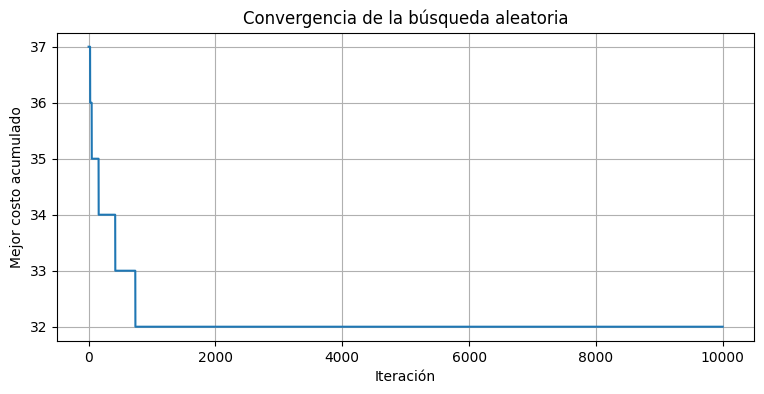

In [14]:
plt.figure(figsize=(9, 4))
plt.plot(historial_aleatorio)
plt.xlabel("Iteración")
plt.ylabel("Mejor costo acumulado")
plt.title("Convergencia de la búsqueda aleatoria")
plt.grid(True)
plt.show()

### Pregunta 9 (*)

**Calcular la complejidad del algoritmo.**

Para la búsqueda aleatoria, sea:

- I: número de iteraciones.
- n: número de tomas.
- m: número de actores.

En cada iteración se realizan dos operaciones principales. Primero, se genera una permutación aleatoria de las n tomas, lo que tiene un costo de O(n). Después, se evalúa la solución mediante la función objetivo. Para calcular el costo es necesario recorrer las tomas organizadas por día y comprobar qué actores participan, lo que requiere aproximadamente O(n⋅m).

Por tanto, la complejidad temporal total de la búsqueda aleatoria es:

$$O(I⋅n⋅m)$$

Como el término O(n⋅m) domina al costo de generación $O(n)$, la expresión anterior representa adecuadamente el costo total del algoritmo.

En el problema original, n=30 y m=10, por lo que ambos valores son fijos. En ese caso, la complejidad puede interpretarse como lineal respecto del número de iteraciones:

$$O(I)$$

Esto mejora ampliamente a la fuerza bruta, cuya complejidad es factorial. Sin embargo, la mejora se obtiene a cambio de perder la garantía de encontrar la solución óptima global.

**Complejidad espacial**

El algoritmo almacena:

- la solución actual: O(n);
- la mejor solución: O(n);
- el historial de costos: O(I).

Por tanto, la complejidad espacial de la implementación es:

$$O(n+I)$$

Si no se almacenara el historial, la memoria se reduciría a:

$$O(n)$$

### Pregunta 10

**Según el problema, diseña un juego de datos de entrada aleatorio.**

Se diseñó un juego de datos aleatorio manteniendo la misma estructura del problema original: 30 tomas y 10 actores. La participación de los actores se representa mediante una matriz binaria, donde cada elemento toma el valor 1 si el actor participa en una determinada toma y 0 en caso contrario. Para generar datos razonables, se utiliza una probabilidad de participación del 30 %. Además, se incorporan validaciones para asegurar que cada toma cuente con al menos un actor y que todos los actores participen en alguna toma. Este conjunto de datos permitirá comprobar el comportamiento del algoritmo ante una instancia diferente de la proporcionada originalmente.


In [15]:
def generar_datos_aleatorios(
    num_tomas=30,
    num_actores=10,
    prob_participacion=0.30,
    semilla=None
):
    """
    Genera una matriz binaria aleatoria de participación actor-toma.

    Garantiza que:
    - cada toma tenga al menos un actor;
    - cada actor participe en al menos una toma.
    """

    rng = np.random.default_rng(semilla)

    matriz = (
        rng.random((num_tomas, num_actores))
        < prob_participacion
    ).astype(int)

    # Garantizar al menos un actor por toma
    for toma in range(num_tomas):
        if matriz[toma].sum() == 0:
            actor = rng.integers(0, num_actores)
            matriz[toma, actor] = 1

    # Garantizar al menos una toma por actor
    for actor in range(num_actores):
        if matriz[:, actor].sum() == 0:
            toma = rng.integers(0, num_tomas)
            matriz[toma, actor] = 1

    columnas = [str(actor) for actor in range(1, num_actores + 1)]

    df_aleatorio = pd.DataFrame(
        matriz,
        columns=columnas
    )

    df_aleatorio.insert(
        0,
        "Toma",
        range(1, num_tomas + 1)
    )

    return matriz, df_aleatorio

**Generación de juego de datos**

In [16]:
A_ALEATORIA, df_aleatorio = generar_datos_aleatorios(
    num_tomas=30,
    num_actores=10,
    prob_participacion=0.30,
    semilla=42
)

print("Dimensiones:", A_ALEATORIA.shape)
display(df_aleatorio.head(10))

Dimensiones: (30, 10)


,Toma,1,2,3,4,5,6,7,8,9,10
0,1,0,0,0,0,1,0,0,0,1,0
1,2,0,0,0,0,0,1,0,1,0,0
2,3,0,0,0,0,0,1,0,1,1,0
3,4,0,0,0,0,0,1,1,0,1,0
4,5,0,0,0,0,0,0,0,1,0,1
5,6,1,1,0,0,0,0,0,0,1,1
6,7,0,0,0,0,0,0,0,0,1,0
7,8,1,0,0,1,1,1,1,0,0,0
8,9,0,0,0,1,1,1,0,0,1,0
9,10,1,0,0,0,0,0,0,1,1,0


### Pregunta 11

**Aplica el algoritmo al juego de datos aleatorio generado.**

El algoritmo de búsqueda aleatoria se aplicó al conjunto de datos sintético generado en la pregunta anterior. Para ello, se evaluaron 10.000 planificaciones aleatorias válidas, conservando aquella que produjo el menor número total de asistencias actor-día. La ejecución permite comprobar que el algoritmo puede utilizarse sobre diferentes instancias del problema, siempre que mantengan la misma estructura de datos. Debido a la naturaleza aleatoria del método, el resultado puede variar entre ejecuciones cuando no se utiliza una semilla fija.

**Funciones para evaluar los datos aleatorios**

In [17]:
def calcular_costo_con_matriz(
    solucion,
    matriz,
    tomas_por_dia=6
):
    """
    Calcula el costo de una solución usando una matriz
    de participación específica.
    """
    num_tomas = matriz.shape[0]
    num_dias = num_tomas // tomas_por_dia

    if len(solucion) != num_tomas:
        raise ValueError(
            "La solución no contiene el número correcto de tomas."
        )

    if set(solucion) != set(range(num_tomas)):
        raise ValueError(
            "La solución contiene tomas repetidas, faltantes o inválidas."
        )

    costo_total = 0

    for dia in range(num_dias):
        inicio = dia * tomas_por_dia
        fin = inicio + tomas_por_dia
        tomas_dia = solucion[inicio:fin]

        actores_presentes = np.any(
            matriz[tomas_dia, :] == 1,
            axis=0
        )

        costo_total += int(np.sum(actores_presentes))

    return costo_total

In [18]:
def busqueda_aleatoria_con_matriz(
    matriz,
    iteraciones=10_000,
    tomas_por_dia=6,
    semilla=None
):
    """
    Aplica búsqueda aleatoria a una matriz de participación.
    """
    if iteraciones <= 0:
        raise ValueError(
            "El número de iteraciones debe ser positivo."
        )

    rng = random.Random(semilla)

    num_tomas = matriz.shape[0]
    mejor_solucion = None
    mejor_costo = float("inf")
    historial = []

    for _ in range(iteraciones):
        solucion = list(range(num_tomas))
        rng.shuffle(solucion)

        costo = calcular_costo_con_matriz(
            solucion,
            matriz,
            tomas_por_dia
        )

        if costo < mejor_costo:
            mejor_solucion = solucion.copy()
            mejor_costo = costo

        historial.append(mejor_costo)

    return mejor_solucion, mejor_costo, historial

**Ejecución**

In [19]:
ITERACIONES_ALEATORIAS = 10000
SEMILLA_BUSQUEDA = 42

inicio = time.perf_counter()

mejor_solucion_datos_aleatorios, mejor_costo_datos_aleatorios, historial_datos_aleatorios = (
    busqueda_aleatoria_con_matriz(
        matriz=A_ALEATORIA,
        iteraciones=ITERACIONES_ALEATORIAS,
        tomas_por_dia=6,
        semilla=SEMILLA_BUSQUEDA
    )
)

tiempo_datos_aleatorios = time.perf_counter() - inicio

print("Iteraciones:", ITERACIONES_ALEATORIAS)
print("Mejor costo encontrado:", mejor_costo_datos_aleatorios)
print(
    f"Tiempo de ejecución: "
    f"{tiempo_datos_aleatorios:.4f} segundos"
)

Iteraciones: 10000
Mejor costo encontrado: 39
Tiempo de ejecución: 1.0935 segundos


In [20]:
def mostrar_planificacion_con_matriz(
    solucion,
    matriz,
    tomas_por_dia=6
):
    num_tomas = matriz.shape[0]
    num_dias = num_tomas // tomas_por_dia

    for dia in range(num_dias):
        inicio = dia * tomas_por_dia
        fin = inicio + tomas_por_dia
        tomas_dia = solucion[inicio:fin]

        mascara_actores = np.any(
            matriz[tomas_dia, :] == 1,
            axis=0
        )

        actores_dia = np.where(mascara_actores)[0]

        print(f"\nDía {dia + 1}")
        print(
            "Tomas:",
            [int(toma + 1) for toma in tomas_dia]
        )
        print(
            "Actores:",
            [int(actor + 1) for actor in actores_dia]
        )
        print(
            "Costo del día:",
            int(np.sum(mascara_actores))
        )

    print(
        "\nCosto total:",
        calcular_costo_con_matriz(
            solucion,
            matriz,
            tomas_por_dia
        )
    )

In [21]:
mostrar_planificacion_con_matriz(
    mejor_solucion_datos_aleatorios,
    A_ALEATORIA,
    tomas_por_dia=6
)


Día 1
Tomas: [29, 27, 6, 26, 30, 8]
Actores: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Costo del día: 10

Día 2
Tomas: [17, 20, 21, 4, 25, 28]
Actores: [1, 2, 3, 4, 5, 6, 7, 9]
Costo del día: 8

Día 3
Tomas: [16, 23, 11, 5, 19, 22]
Actores: [3, 5, 7, 8, 9, 10]
Costo del día: 6

Día 4
Tomas: [7, 15, 18, 9, 24, 13]
Actores: [1, 3, 4, 5, 6, 8, 9, 10]
Costo del día: 8

Día 5
Tomas: [3, 14, 12, 10, 2, 1]
Actores: [1, 2, 5, 6, 8, 9, 10]
Costo del día: 7

Costo total: 39


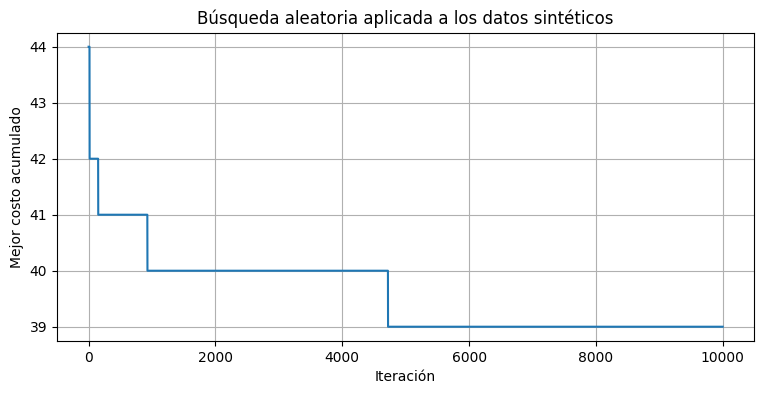

In [22]:
plt.figure(figsize=(9, 4))

plt.plot(historial_datos_aleatorios)

plt.xlabel("Iteración")
plt.ylabel("Mejor costo acumulado")
plt.title(
    "Búsqueda aleatoria aplicada a los datos sintéticos"
)
plt.grid(True)

plt.show()

La búsqueda aleatoria evalúa 10.000 planificaciones válidas y conserva la de menor costo. El valor concreto del costo y el tiempo se obtienen en la celda de ejecución anterior. Como el procedimiento es estocástico, estos valores pueden cambiar cuando no se fija una semilla. El gráfico permite observar que las mejoras suelen concentrarse en las primeras iteraciones y luego se vuelven menos frecuentes.

### Pregunta 12

(Ver sección de referencias)

### Pregunta 13

**Describe brevemente cómo crees que es posible avanzar en el estudio del problema.**

El problema de planificación de sesiones de doblaje puede ampliarse incorporando nuevas restricciones y objetivos que representen de manera más realista un entorno de producción audiovisual. Por ejemplo, podrían considerarse límites de tiempo por jornada, disponibilidad específica de los actores, prioridades entre determinadas tomas o costos diferentes según el actor o el día de grabación. Asimismo, podría abordarse como un problema de optimización multiobjetivo, buscando minimizar simultáneamente el costo de las asistencias y el número de días necesarios para completar la grabación.

Desde el punto de vista algorítmico, el estudio puede continuar evaluando técnicas de optimización más avanzadas, como búsqueda local, recocido simulado, colonia de hormigas y algoritmos genéticos, comparando la calidad de las soluciones obtenidas y los tiempos de ejecución. Para instancias de mayor tamaño, donde aumente el número de tomas o de actores, el uso de metaheurísticas resulta especialmente adecuado, ya que permiten explorar espacios de búsqueda muy grandes obteniendo soluciones de buena calidad en tiempos razonables, aun cuando no garanticen alcanzar el óptimo global.

$\Large \mathbf{2.\ Estrategia\ Recocido \ Simulado}$

Descripción del método

El recocido simulado [14] comienza con una planificación inicial y genera soluciones vecinas intercambiando tomas entre diferentes días. Cuando una solución vecina mejora el costo, se acepta directamente. Cuando empeora, todavía puede aceptarse con una probabilidad:

$$P(\text{aceptar}) = e^{-\frac{\Delta}{T}}$$


donde:

- Δ es el incremento del costo.
- T es la temperatura actual.

Al principio, cuando la temperatura es alta, el algoritmo acepta con mayor facilidad soluciones peores, lo que permite escapar de mínimos locales. A medida que la temperatura disminuye, el comportamiento se vuelve más selectivo.

**Generación de una solución vecina**

Conviene intercambiar tomas que estén en días diferentes, porque intercambiar dos tomas dentro del mismo día no modifica la agrupación ni el costo.

In [23]:
def generar_vecino_intercambio(
    solucion,
    rng,
    tomas_por_dia=6
):
    """Intercambia dos tomas pertenecientes a días distintos."""
    vecino = solucion.copy()
    num_tomas = len(vecino)

    while True:
        posicion_1, posicion_2 = rng.sample(range(num_tomas), 2)

        dia_1 = posicion_1 // tomas_por_dia
        dia_2 = posicion_2 // tomas_por_dia

        if dia_1 != dia_2:
            break

    vecino[posicion_1], vecino[posicion_2] = (
        vecino[posicion_2],
        vecino[posicion_1]
    )

    return vecino


**Algoritmo de recocido simulado**

In [24]:
def recocido_simulado(
    matriz,
    tomas_por_dia=6,
    temperatura_inicial=100.0,
    temperatura_final=0.001,
    factor_enfriamiento=0.995,
    iteraciones_por_temperatura=100,
    semilla=None
):
    """Resuelve una instancia mediante recocido simulado."""
    matriz = np.asarray(matriz, dtype=int)
    num_tomas = matriz.shape[0]

    if num_tomas % tomas_por_dia != 0:
        raise ValueError(
            "El número de tomas debe ser divisible por tomas_por_dia."
        )
    if temperatura_inicial <= 0 or temperatura_final <= 0:
        raise ValueError("Las temperaturas deben ser positivas.")
    if temperatura_final >= temperatura_inicial:
        raise ValueError(
            "La temperatura final debe ser menor que la inicial."
        )
    if not 0 < factor_enfriamiento < 1:
        raise ValueError(
            "El factor de enfriamiento debe estar entre 0 y 1."
        )
    if iteraciones_por_temperatura <= 0:
        raise ValueError(
            "Las iteraciones por temperatura deben ser positivas."
        )

    rng = random.Random(semilla)

    solucion_actual = list(range(num_tomas))
    rng.shuffle(solucion_actual)

    costo_actual = calcular_costo_con_matriz(
        solucion_actual,
        matriz,
        tomas_por_dia
    )

    mejor_solucion = solucion_actual.copy()
    mejor_costo = costo_actual

    temperatura = temperatura_inicial
    historial_mejor = [mejor_costo]
    historial_actual = [costo_actual]

    soluciones_aceptadas = 0
    soluciones_peores_aceptadas = 0
    iteraciones = 0

    while temperatura > temperatura_final:
        for _ in range(iteraciones_por_temperatura):
            vecino = generar_vecino_intercambio(
                solucion_actual,
                rng,
                tomas_por_dia
            )

            costo_vecino = calcular_costo_con_matriz(
                vecino,
                matriz,
                tomas_por_dia
            )

            diferencia = costo_vecino - costo_actual

            if diferencia <= 0:
                aceptar = True
            else:
                probabilidad = np.exp(-diferencia / temperatura)
                aceptar = rng.random() < probabilidad

            if aceptar:
                solucion_actual = vecino
                costo_actual = costo_vecino
                soluciones_aceptadas += 1

                if diferencia > 0:
                    soluciones_peores_aceptadas += 1

                if costo_actual < mejor_costo:
                    mejor_solucion = solucion_actual.copy()
                    mejor_costo = costo_actual

            historial_actual.append(costo_actual)
            historial_mejor.append(mejor_costo)
            iteraciones += 1

        temperatura *= factor_enfriamiento

    return {
        "mejor_solucion": mejor_solucion,
        "mejor_costo": mejor_costo,
        "historial_mejor": historial_mejor,
        "historial_actual": historial_actual,
        "soluciones_aceptadas": soluciones_aceptadas,
        "soluciones_peores_aceptadas": soluciones_peores_aceptadas,
        "iteraciones": iteraciones
    }


**Ejecución**

In [25]:
TEMPERATURA_INICIAL = 100.0
TEMPERATURA_FINAL = 0.001
FACTOR_ENFRIAMIENTO = 0.995
ITERACIONES_POR_TEMPERATURA = 100
SEMILLA_RECOCIDO = 42

inicio = time.perf_counter()

resultado_recocido = recocido_simulado(
    matriz=A,
    tomas_por_dia=TOMAS_POR_DIA,
    temperatura_inicial=TEMPERATURA_INICIAL,
    temperatura_final=TEMPERATURA_FINAL,
    factor_enfriamiento=FACTOR_ENFRIAMIENTO,
    iteraciones_por_temperatura=ITERACIONES_POR_TEMPERATURA,
    semilla=SEMILLA_RECOCIDO
)

tiempo_recocido = time.perf_counter() - inicio

mejor_solucion_recocido = resultado_recocido[
    "mejor_solucion"
]

mejor_costo_recocido = resultado_recocido[
    "mejor_costo"
]

print("Recocido simulado")
print("------------------")
print("Mejor costo encontrado:", mejor_costo_recocido)
print(
    "Mejor solución:",
    [toma + 1 for toma in mejor_solucion_recocido]
)
print("Iteraciones:", resultado_recocido["iteraciones"])
print(
    "Soluciones aceptadas:",
    resultado_recocido["soluciones_aceptadas"]
)
print(
    "Soluciones peores aceptadas:",
    resultado_recocido[
        "soluciones_peores_aceptadas"
    ]
)
print(
    f"Tiempo de ejecución: {tiempo_recocido:.4f} segundos"
)

Recocido simulado
------------------
Mejor costo encontrado: 27
Mejor solución: [29, 4, 21, 3, 8, 15, 2, 12, 26, 10, 20, 13, 14, 23, 24, 19, 18, 17, 11, 5, 30, 22, 1, 28, 9, 16, 25, 7, 27, 6]
Iteraciones: 229700
Soluciones aceptadas: 105802
Soluciones peores aceptadas: 20093
Tiempo de ejecución: 13.2028 segundos


**Planificación obtenida**

In [26]:
mostrar_planificacion(
    mejor_solucion_recocido
)


Día 1
Tomas: [29, 4, 21, 3, 8, 15]
Actores: [1, 2, 5, 6, 7, 8]
Costo del día: 6

Día 2
Tomas: [2, 12, 26, 10, 20, 13]
Actores: [1, 2, 3, 4, 5, 6, 9]
Costo del día: 7

Día 3
Tomas: [14, 23, 24, 19, 18, 17]
Actores: [1, 3, 6]
Costo del día: 3

Día 4
Tomas: [11, 5, 30, 22, 1, 28]
Actores: [1, 2, 3, 4, 5, 8]
Costo del día: 6

Día 5
Tomas: [9, 16, 25, 7, 27, 6]
Actores: [1, 2, 4, 5, 10]
Costo del día: 5

Costo total: 27


**Gráfico de convergencia**

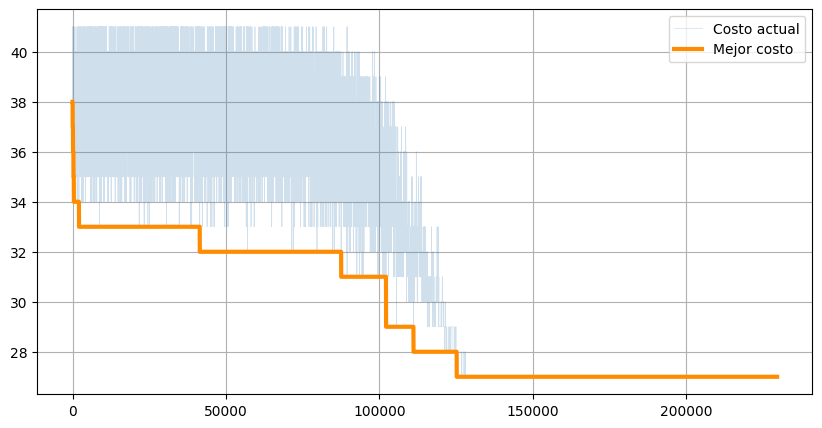

In [27]:
plt.figure(figsize=(10,5))

plt.plot(
    resultado_recocido["historial_actual"],
    color="steelblue",
    alpha=0.25,
    linewidth=0.5,
    label="Costo actual"
)

plt.plot(
    resultado_recocido["historial_mejor"],
    color="darkorange",
    linewidth=3,
    label="Mejor costo"
)

plt.grid(True)
plt.legend()

El recocido simulado [14] se aplicó al problema de organización de sesiones de doblaje representando cada solución como una permutación de las 30 tomas, dividida en cinco bloques consecutivos de seis tomas. Para generar una solución vecina se intercambiaron dos tomas pertenecientes a días diferentes, manteniendo así todas las restricciones del problema. Las soluciones que disminuyen o mantienen el costo se aceptan directamente, mientras que las soluciones peores pueden aceptarse con una probabilidad dependiente de la temperatura. Este mecanismo permite escapar de mínimos locales durante las primeras etapas del proceso. A medida que la temperatura disminuye, la probabilidad de aceptar empeoramientos se reduce y el algoritmo concentra la búsqueda alrededor de las mejores planificaciones encontradas.

Las preguntas del 1 a 7 fueron contestadas en el apartado de Análisis general del problema, datos, y resolver el problema por fuerza bruta, (Parte I a Parte III (relacionados a la pregunta 6 y 7)). Por lo tannto comenzaremos respondiendo a partir de la pregunta 8 para el caso.

### Pregunta 8 (*)

**Diseñar un algoritmo que mejore la complejidad del algoritmo por fuerza bruta. Argumenta por qué mejora al algoritmo por fuerza bruta.**

Se diseñó un algoritmo basado en la metaheurística de recocido simulado (Simulated Annealing) para resolver el problema de organización de sesiones de doblaje. El algoritmo comienza con una planificación inicial de las tomas y, en cada iteración, genera una solución vecina intercambiando dos tomas pertenecientes a días distintos. Si la nueva planificación reduce el costo, se acepta directamente; si lo incrementa, aún puede aceptarse con una probabilidad que depende de la temperatura del sistema. Esta estrategia permite escapar de mínimos locales y explorar una mayor parte del espacio de búsqueda.

El recocido simulado mejora al algoritmo de fuerza bruta porque no necesita evaluar todas las posibles planificaciones, cuyo número crece factorialmente con el número de tomas. En su lugar, realiza una exploración guiada mediante una cantidad controlada de iteraciones, obteniendo soluciones de alta calidad con un tiempo de ejecución muy inferior.

### Pregunta 9 (*)

**Calcula la complejidad del algoritmo.**

Sea:

- n: número de tomas.
- m: número de actores.
- I: número total de iteraciones del recocido simulado.

En cada iteración se realizan las siguientes operaciones:

generar un vecino mediante un intercambio: O(1);
calcular el costo de la solución: O(n·m).

Por lo tanto, el costo de una iteración es:

$$O(n⋅m)$$

Como el algoritmo ejecuta aproximadamente $I$ iteraciones, la complejidad total es:

$$\boxed{O(I \cdot n \cdot m)}$$

En este problema:
* $n = 30$
* $m = 10$

por lo que el tiempo de ejecución depende principalmente del número de iteraciones configuradas.

Esta complejidad representa una mejora considerable respecto a la fuerza bruta, cuya complejidad es factorial.


### Pregunta 10

**Según el problema, diseña un juego de datos de entrada aleatoria.**

Para evaluar el comportamiento del algoritmo en distintos escenarios y no depender únicamente del conjunto de datos proporcionado en el enunciado, se diseñó una función que genera de forma aleatoria la matriz de participación de actores en las tomas. En esta matriz, cada fila representa una toma y cada columna un actor. Los valores son binarios: un 1 indica que el actor participa en la toma y un 0 indica que no participa.

La generación de los datos mantiene la estructura del problema original, considerando 30 tomas y 10 actores. Además, se garantiza que cada toma tenga al menos un actor asignado, evitando generar tomas vacías que no tendrían sentido dentro del problema. Este conjunto de datos permite comprobar que el algoritmo de recocido simulado puede aplicarse correctamente a diferentes configuraciones de entrada.

In [28]:
# Se reutiliza el conjunto A_ALEATORIA generado en la Pregunta 10.
print("Dimensiones de la matriz aleatoria:", A_ALEATORIA.shape)
display(df_aleatorio.head())


Dimensiones de la matriz aleatoria: (30, 10)


,Toma,1,2,3,4,5,6,7,8,9,10
0,1,0,0,0,0,1,0,0,0,1,0
1,2,0,0,0,0,0,1,0,1,0,0
2,3,0,0,0,0,0,1,0,1,1,0
3,4,0,0,0,0,0,1,1,0,1,0
4,5,0,0,0,0,0,0,0,1,0,1


In [29]:
print("Número de tomas:", A_ALEATORIA.shape[0])
print("Número de actores:", A_ALEATORIA.shape[1])


Número de tomas: 30
Número de actores: 10


### Pregunta 11

**Aplica el algoritmo al juego de datos aleatorio generado.**

Se aplicó el algoritmo de recocido simulado sobre el conjunto de datos generado aleatoriamente, manteniendo la misma configuración de parámetros utilizada en el problema original. El objetivo fue comprobar que el algoritmo es capaz de encontrar una planificación de las sesiones de doblaje minimizando el costo total asociado a la asistencia de los actores, independientemente del conjunto de datos utilizado.

Durante la ejecución, el algoritmo exploró diferentes configuraciones mediante el intercambio de tomas entre días. En las primeras etapas aceptó algunas soluciones de mayor costo debido a la alta temperatura inicial, lo que permitió explorar una mayor parte del espacio de búsqueda y evitar quedar atrapado en mínimos locales. A medida que la temperatura disminuyó, el algoritmo fue aceptando principalmente soluciones que reducían el costo, hasta converger hacia una planificación estable.

Los resultados obtenidos muestran que el algoritmo mantiene un comportamiento consistente al trabajar con datos generados aleatoriamente, produciendo soluciones factibles y de buena calidad en un tiempo de ejecución reducido. Esto evidencia que el método propuesto no depende exclusivamente del conjunto de datos del enunciado y puede aplicarse a diferentes instancias del problema.

In [30]:
inicio = time.perf_counter()

resultado_recocido_aleatorio = recocido_simulado(
    matriz=A_ALEATORIA,
    tomas_por_dia=6,
    temperatura_inicial=100.0,
    temperatura_final=0.001,
    factor_enfriamiento=0.995,
    iteraciones_por_temperatura=100,
    semilla=42
)

tiempo_recocido_aleatorio = time.perf_counter() - inicio

print("Mejor costo:", resultado_recocido_aleatorio["mejor_costo"])
print("Iteraciones:", resultado_recocido_aleatorio["iteraciones"])
print(
    "Soluciones aceptadas:",
    resultado_recocido_aleatorio["soluciones_aceptadas"]
)
print(
    "Soluciones peores aceptadas:",
    resultado_recocido_aleatorio["soluciones_peores_aceptadas"]
)
print(
    f"Tiempo de ejecución: {tiempo_recocido_aleatorio:.4f} segundos"
)

mostrar_planificacion_con_matriz(
    resultado_recocido_aleatorio["mejor_solucion"],
    A_ALEATORIA,
    tomas_por_dia=6
)


Mejor costo: 32
Iteraciones: 229700
Soluciones aceptadas: 94912
Soluciones peores aceptadas: 25044
Tiempo de ejecución: 13.0570 segundos

Día 1
Tomas: [26, 11, 22, 25, 1, 13]
Actores: [3, 4, 5, 7, 8, 9]
Costo del día: 6

Día 2
Tomas: [2, 3, 15, 19, 5, 7]
Actores: [6, 8, 9, 10]
Costo del día: 4

Día 3
Tomas: [12, 14, 6, 20, 24, 18]
Actores: [1, 2, 3, 5, 6, 9, 10]
Costo del día: 7

Día 4
Tomas: [28, 17, 30, 16, 23, 29]
Actores: [1, 2, 3, 4, 5, 7, 10]
Costo del día: 7

Día 5
Tomas: [8, 9, 4, 27, 21, 10]
Actores: [1, 4, 5, 6, 7, 8, 9, 10]
Costo del día: 8

Costo total: 32


**Análisis de los resultados**

El algoritmo produjo una planificación válida para el conjunto de datos aleatorio generado, respetando las restricciones del problema. La evolución del costo mostró una reducción progresiva hasta alcanzar una solución estable, confirmando la capacidad del recocido simulado para adaptarse a diferentes configuraciones de entrada. Aunque los valores obtenidos pueden variar en cada ejecución debido al carácter estocástico del algoritmo, en todos los casos se observó una mejora significativa respecto a la solución inicial.

### Pregunta 12

(Ver sección de referencias)

### Pregunta 13

**Describe brevemente cómo es posible avanzar en el estudio del problema.**

El estudio del problema puede ampliarse considerando instancias de mayor tamaño, con más actores, más tomas y un mayor número de días de grabación. Al aumentar estas dimensiones, el espacio de soluciones crece rápidamente y se hace aún menos viable utilizar métodos exactos o de fuerza bruta, por lo que resulta conveniente estudiar y comparar diferentes metaheurísticas.

Una posible línea de avance consiste en comparar el recocido simulado con otros métodos, como algoritmos genéticos, búsqueda tabú, búsqueda en entornos variables o colonia de hormigas. También sería interesante desarrollar métodos híbridos, por ejemplo, combinando recocido simulado con una búsqueda local que mejore cada solución aceptada.

Además, pueden incorporarse nuevas condiciones más cercanas a un escenario real, como diferentes costos por actor, disponibilidad limitada, duración variable de las tomas, número máximo de horas de grabación por día, prioridad de algunas escenas o restricciones que obliguen a grabar determinadas tomas en un orden específico.

Finalmente, se podrían realizar varias ejecuciones con distintas semillas y configuraciones de parámetros para analizar la estabilidad del algoritmo, la calidad promedio de las soluciones y el tiempo de ejecución. Esto permitiría determinar qué configuración ofrece el mejor equilibrio entre costo computacional y calidad de la planificación obtenida.

$\Large \mathbf{3.\ Estrategia\ Algoritmo \ Genético}$

**Generación de población inicial** [9, 12]

In [31]:
def generar_poblacion(tam_poblacion, num_tomas, rng):
    """Genera una población inicial de permutaciones válidas."""
    poblacion = []

    for _ in range(tam_poblacion):
        individuo = list(range(num_tomas))
        rng.shuffle(individuo)
        poblacion.append(individuo)

    return poblacion

**Selección por torneo**

La selección por torneo elige varios individuos al azar [9, 12] y conserva el que tenga menor costo.

In [32]:
def seleccion_torneo(
    poblacion,
    costos,
    rng,
    tam_torneo=3
):
    """
    Selecciona un individuo mediante torneo.
    Como el problema es de minimización, gana el de menor costo.
    """
    indices = rng.sample(
        range(len(poblacion)),
        tam_torneo
    )

    mejor_indice = min(
        indices,
        key=lambda indice: costos[indice]
    )

    return poblacion[mejor_indice].copy()

**Cruce ordenado**

Como cada individuo es una permutación, no conviene utilizar un cruce tradicional de un punto, porque podría producir tomas repetidas. Utilizaremos el cruce ordenado u Ordered Crossover [9, 12].

In [33]:
def cruce_ordenado(padre_1, padre_2, rng):
    """Aplica cruce ordenado OX en tiempo lineal."""
    n = len(padre_1)
    punto_1, punto_2 = sorted(rng.sample(range(n), 2))

    def construir_hijo(padre_a, padre_b):
        hijo = [None] * n
        segmento = padre_a[punto_1:punto_2 + 1]
        hijo[punto_1:punto_2 + 1] = segmento
        usados = set(segmento)

        posiciones = (
            list(range(punto_2 + 1, n))
            + list(range(0, punto_1))
        )

        genes_b = (
            padre_b[punto_2 + 1:]
            + padre_b[:punto_2 + 1]
        )
        restantes = [gen for gen in genes_b if gen not in usados]

        for posicion, gen in zip(posiciones, restantes):
            hijo[posicion] = gen

        return hijo

    return (
        construir_hijo(padre_1, padre_2),
        construir_hijo(padre_2, padre_1)
    )


**Mutación**

La mutación [9, 12] intercambiará dos tomas de días diferentes.

In [34]:
def mutar_individuo(
    individuo,
    prob_mutacion,
    rng,
    tomas_por_dia=6
):
    """Aplica una mutación por intercambio entre días distintos."""
    mutado = individuo.copy()

    if rng.random() < prob_mutacion:
        num_tomas = len(mutado)

        while True:
            posicion_1, posicion_2 = rng.sample(
                range(num_tomas),
                2
            )

            dia_1 = posicion_1 // tomas_por_dia
            dia_2 = posicion_2 // tomas_por_dia

            if dia_1 != dia_2:
                break

        mutado[posicion_1], mutado[posicion_2] = (
            mutado[posicion_2],
            mutado[posicion_1]
        )

    return mutado


No sería incorrecto intercambiar dos posiciones del mismo día, pero el costo no cambiaría porque las tomas continuarían agrupadas en esa misma jornada. Por eso se obliga a seleccionar días distintos.

**Algoritmo genético completo**

In [35]:
def algoritmo_genetico(
    matriz,
    tomas_por_dia=6,
    tam_poblacion=500,
    generaciones=1000,
    prob_cruce=0.9,
    prob_mutacion=0.25,
    elitismo=10,
    tam_torneo=3,
    limite_sin_mejora=200,
    semilla=None
):
    """Resuelve una instancia mediante un algoritmo genético."""
    matriz = np.asarray(matriz, dtype=int)
    num_tomas = matriz.shape[0]

    if num_tomas % tomas_por_dia != 0:
        raise ValueError(
            "El número de tomas debe ser divisible por tomas_por_dia."
        )
    if tam_poblacion < 2:
        raise ValueError(
            "El tamaño de la población debe ser al menos 2."
        )
    if generaciones <= 0:
        raise ValueError(
            "El número de generaciones debe ser positivo."
        )
    if not 0 <= prob_cruce <= 1:
        raise ValueError(
            "La probabilidad de cruce debe estar entre 0 y 1."
        )
    if not 0 <= prob_mutacion <= 1:
        raise ValueError(
            "La probabilidad de mutación debe estar entre 0 y 1."
        )
    if elitismo < 0 or elitismo >= tam_poblacion:
        raise ValueError(
            "El elitismo debe estar entre 0 y tam_poblacion - 1."
        )
    if tam_torneo < 2 or tam_torneo > tam_poblacion:
        raise ValueError(
            "El tamaño del torneo no es válido."
        )
    if limite_sin_mejora is not None and limite_sin_mejora <= 0:
        raise ValueError(
            "El límite sin mejora debe ser positivo o None."
        )

    rng = random.Random(semilla)

    poblacion = generar_poblacion(
        tam_poblacion,
        num_tomas,
        rng
    )

    def costo(individuo):
        return calcular_costo_con_matriz(
            individuo,
            matriz,
            tomas_por_dia
        )

    costos = [costo(individuo) for individuo in poblacion]

    mejor_indice = int(np.argmin(costos))
    mejor_individuo = poblacion[mejor_indice].copy()
    mejor_costo = costos[mejor_indice]

    historial_mejor = [mejor_costo]
    historial_promedio = [float(np.mean(costos))]

    generaciones_sin_mejora = 0
    generaciones_ejecutadas = 0

    for generacion in range(generaciones):
        indices_ordenados = sorted(
            range(tam_poblacion),
            key=lambda indice: costos[indice]
        )

        nueva_poblacion = [
            poblacion[indice].copy()
            for indice in indices_ordenados[:elitismo]
        ]

        while len(nueva_poblacion) < tam_poblacion:
            padre_1 = seleccion_torneo(
                poblacion,
                costos,
                rng,
                tam_torneo
            )
            padre_2 = seleccion_torneo(
                poblacion,
                costos,
                rng,
                tam_torneo
            )

            if rng.random() < prob_cruce:
                hijo_1, hijo_2 = cruce_ordenado(
                    padre_1,
                    padre_2,
                    rng
                )
            else:
                hijo_1 = padre_1.copy()
                hijo_2 = padre_2.copy()

            hijo_1 = mutar_individuo(
                hijo_1,
                prob_mutacion,
                rng,
                tomas_por_dia
            )
            hijo_2 = mutar_individuo(
                hijo_2,
                prob_mutacion,
                rng,
                tomas_por_dia
            )

            nueva_poblacion.append(hijo_1)

            if len(nueva_poblacion) < tam_poblacion:
                nueva_poblacion.append(hijo_2)

        poblacion = nueva_poblacion
        costos = [costo(individuo) for individuo in poblacion]

        mejor_indice_generacion = int(np.argmin(costos))
        mejor_costo_generacion = costos[
            mejor_indice_generacion
        ]

        if mejor_costo_generacion < mejor_costo:
            mejor_costo = mejor_costo_generacion
            mejor_individuo = poblacion[
                mejor_indice_generacion
            ].copy()
            generaciones_sin_mejora = 0
        else:
            generaciones_sin_mejora += 1

        historial_mejor.append(mejor_costo)
        historial_promedio.append(float(np.mean(costos)))
        generaciones_ejecutadas = generacion + 1

        if (
            limite_sin_mejora is not None
            and generaciones_sin_mejora >= limite_sin_mejora
        ):
            break

    return {
        "mejor_individuo": mejor_individuo,
        "mejor_costo": mejor_costo,
        "historial_mejor": historial_mejor,
        "historial_promedio": historial_promedio,
        "generaciones_ejecutadas": generaciones_ejecutadas,
        "generaciones_sin_mejora": generaciones_sin_mejora
    }


**Ejecución del algoritmo genético** [9, 12]

In [36]:
inicio = time.perf_counter()

resultado_genetico = algoritmo_genetico(
    matriz=A,
    tomas_por_dia=TOMAS_POR_DIA,
    tam_poblacion=500,
    generaciones=1000,
    prob_cruce=0.9,
    prob_mutacion=0.25,
    elitismo=10,
    tam_torneo=3,
    limite_sin_mejora=200,
    semilla=None
)

tiempo_genetico = time.perf_counter() - inicio

mejor_individuo_genetico = resultado_genetico[
    "mejor_individuo"
]
mejor_costo_genetico = resultado_genetico[
    "mejor_costo"
]

print("Algoritmo genético")
print("------------------")
print("Mejor costo encontrado:", mejor_costo_genetico)
print(
    "Mejor solución:",
    [int(toma + 1) for toma in mejor_individuo_genetico]
)
print(
    "Generaciones ejecutadas:",
    resultado_genetico["generaciones_ejecutadas"]
)
print(
    "Generaciones sin mejora:",
    resultado_genetico["generaciones_sin_mejora"]
)
print(f"Tiempo de ejecución: {tiempo_genetico:.4f} segundos")

mostrar_planificacion(mejor_individuo_genetico)


Algoritmo genético
------------------
Mejor costo encontrado: 27
Mejor solución: [20, 1, 22, 2, 13, 12, 15, 3, 28, 4, 9, 5, 16, 7, 25, 30, 27, 6, 10, 8, 29, 21, 11, 26, 18, 24, 23, 19, 14, 17]
Generaciones ejecutadas: 236
Generaciones sin mejora: 200
Tiempo de ejecución: 7.5428 segundos

Día 1
Tomas: [20, 1, 22, 2, 13, 12]
Actores: [1, 2, 3, 4, 5, 6]
Costo del día: 6

Día 2
Tomas: [15, 3, 28, 4, 9, 5]
Actores: [1, 2, 4, 5, 7, 8]
Costo del día: 6

Día 3
Tomas: [16, 7, 25, 30, 27, 6]
Actores: [1, 2, 4, 5, 10]
Costo del día: 5

Día 4
Tomas: [10, 8, 29, 21, 11, 26]
Actores: [1, 2, 3, 5, 6, 8, 9]
Costo del día: 7

Día 5
Tomas: [18, 24, 23, 19, 14, 17]
Actores: [1, 3, 6]
Costo del día: 3

Costo total: 27


El algoritmo genético es estocástico. Por ello, el mejor costo, el número de generaciones ejecutadas y el tiempo pueden variar entre corridas cuando no se fija una semilla. Los valores concretos deben tomarse de la salida de la celda anterior. Como referencia, el costo puede compararse con el óptimo conocido obtenido mediante el método exacto.

**Gráfico de convergencia**

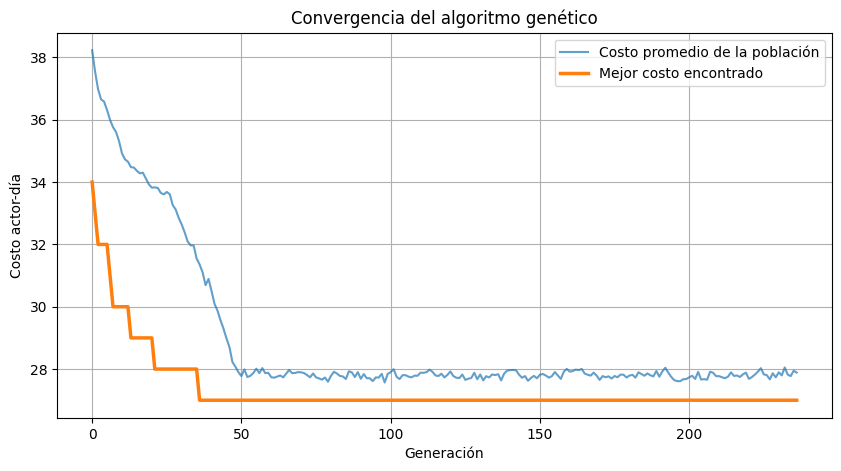

In [37]:
plt.figure(figsize=(10, 5))

plt.plot(
    resultado_genetico["historial_promedio"],
    alpha=0.7,
    label="Costo promedio de la población"
)

plt.plot(
    resultado_genetico["historial_mejor"],
    linewidth=2.5,
    label="Mejor costo encontrado"
)

plt.xlabel("Generación")
plt.ylabel("Costo actor-día")
plt.title("Convergencia del algoritmo genético")
plt.legend()
plt.grid(True)

plt.show()

En el gráfico:

- el costo promedio muestra la evolución general de la población;
- el mejor costo debe mantenerse o disminuir debido al elitismo;
- una estabilización prolongada indica que la población probablemente convergió.

Para resolver el problema de organización de sesiones de doblaje se implementó un algoritmo genético [9, 12]. Cada individuo se representó mediante una permutación de las 30 tomas, dividida en cinco bloques consecutivos de seis tomas, correspondientes a los cinco días de grabación. La población inicial se generó aleatoriamente y la calidad de cada individuo se evaluó mediante el costo total de asistencias actor-día. La selección de los padres se realizó por torneo y se utilizó el cruce ordenado OX, adecuado para individuos representados mediante permutaciones. La mutación consistió en intercambiar dos tomas pertenecientes a días distintos. Además, se incorporó elitismo para conservar las mejores soluciones y un criterio de parada basado en generaciones consecutivas sin mejora. De esta forma, el algoritmo explora diferentes planificaciones sin evaluar exhaustivamente todo el espacio de soluciones.

Las preguntas del 1 a 7 fueron contestadas en el apartado de Análisis general del problema, datos, y resolver el problema por fuerza bruta, (Parte I a Parte III (relacionados a la pregunta 6 y 7)). Por lo tannto comenzaremos respondiendo a partir de la pregunta 8 para el caso.

### Pregunta 8 (*)

**Diseña un algoritmo que mejore la complejidad del algoritmo por fuerza bruta.
      Argumenta porque crees que mejora al algoritmo por fuerza bruta.**

Se propone un algoritmo genético porque evita enumerar las \(30!\) permutaciones. Cada individuo es una permutación de las 30 tomas dividida en cinco bloques de seis. La población evoluciona mediante selección por torneo, cruce ordenado OX, mutación por intercambio y elitismo. El método mejora la viabilidad computacional respecto de la fuerza bruta, aunque no garantiza encontrar el óptimo en todas las ejecuciones.

### Pregunta 9 (*)

**Calcula la complejidad del algoritmo.**

Sea $P$ el tamaño de población, $G$ el máximo de generaciones, $n$ el número de tomas y $m$ el número de actores. Evaluar un individuo cuesta $O(nm)$. En cada generación se evalúan $P$ individuos, se ordena la población en $O(P\log P)$, y los operadores de cruce y mutación requieren $O(Pn)$.

Por tanto, la complejidad temporal de esta implementación es:

$$
\boxed{O\left(G\left(Pnm+Pn+P\log P\right)\right)}
$$

que puede resumirse como $O(GP(nm+\log P))$. Si $n$ y $m$ se consideran fijos, el tiempo depende principalmente de $G$ y $P$.

### Pregunta 10

Para el algoritmo genético se utiliza el mismo juego de datos sintético generado anteriormente: una matriz binaria de 30 tomas por 10 actores, con al menos un actor por toma y al menos una toma por actor.

### Pregunta 11

A continuación se aplica el algoritmo genético al juego de datos aleatorio generado en la Pregunta 10.

In [38]:
inicio = time.perf_counter()

resultado_genetico_aleatorio = algoritmo_genetico(
    matriz=A_ALEATORIA,
    tomas_por_dia=6,
    tam_poblacion=500,
    generaciones=1000,
    prob_cruce=0.9,
    prob_mutacion=0.25,
    elitismo=10,
    tam_torneo=3,
    limite_sin_mejora=200,
    semilla=42
)

tiempo_genetico_aleatorio = time.perf_counter() - inicio

print(
    "Mejor costo:",
    resultado_genetico_aleatorio["mejor_costo"]
)
print(
    "Generaciones ejecutadas:",
    resultado_genetico_aleatorio["generaciones_ejecutadas"]
)
print(
    f"Tiempo de ejecución: {tiempo_genetico_aleatorio:.4f} segundos"
)

mostrar_planificacion_con_matriz(
    resultado_genetico_aleatorio["mejor_individuo"],
    A_ALEATORIA,
    tomas_por_dia=6
)


Mejor costo: 33
Generaciones ejecutadas: 231
Tiempo de ejecución: 7.6599 segundos

Día 1
Tomas: [30, 17, 29, 22, 16, 5]
Actores: [1, 2, 3, 4, 5, 7, 8, 10]
Costo del día: 8

Día 2
Tomas: [1, 25, 11, 7, 26, 13]
Actores: [3, 4, 5, 8, 9]
Costo del día: 5

Día 3
Tomas: [19, 14, 2, 3, 10, 24]
Actores: [1, 6, 8, 9, 10]
Costo del día: 5

Día 4
Tomas: [21, 8, 27, 9, 4, 23]
Actores: [1, 4, 5, 6, 7, 8, 9, 10]
Costo del día: 8

Día 5
Tomas: [15, 18, 28, 20, 12, 6]
Actores: [1, 2, 3, 5, 6, 9, 10]
Costo del día: 7

Costo total: 33


### Pregunta 12

Las referencias empleadas se enumeran en la sección de referencias.

### Pregunta 13

El estudio puede ampliarse aumentando el número de tomas y actores, incorporando disponibilidad de actores, duraciones diferentes, costos variables y restricciones de precedencia. También sería útil ejecutar varias corridas del algoritmo genético y comparar media, desviación estándar, mejor resultado, peor resultado y tiempo de ejecución. Para instancias mayores pueden estudiarse algoritmos meméticos, búsqueda tabú, recocido simulado adaptativo y modelos híbridos con programación entera.

$\Large \mathbf{4.\ Estrategia\ Algoritmo \ Colonia \ de \ Hormigas}$

**Descripción del método**

La optimización por colonia de hormigas (ACO) [7-8] es una metaheurística constructiva inspirada en el comportamiento de las hormigas reales. Cada hormiga construye una planificación completa seleccionando progresivamente las tomas. La elección de la siguiente toma depende de dos elementos:

- **Feromona**: memoria colectiva que favorece combinaciones de tomas que aparecieron juntas en buenas soluciones anteriores.
- **Información heurística**: preferencia por incorporar una toma que aumente lo menos posible el número de actores necesarios en el día que se está construyendo.

En este problema, una solución continúa representándose mediante una permutación de las 30 tomas. Cada bloque consecutivo de seis posiciones corresponde a un día. A diferencia del TSP mostrado en el notebook de apoyo, el orden interno de las tomas de un día no modifica el costo. Por ello, la feromona se deposita entre **todas las parejas de tomas que quedan agrupadas en un mismo día**, no únicamente entre posiciones consecutivas.

**Información heurística**

Cuando una hormiga debe elegir una nueva toma, se calcula el costo incremental que produciría añadirla al día actual. Si los actores de esa toma ya están presentes por otras tomas del mismo día, el incremento será pequeño o incluso cero.

Para una toma candidata $j$ se utiliza:

$$
\eta_j = \frac{1}{1 + \Delta_j}
$$

siendo $\Delta_j$ el número de actores nuevos que sería necesario convocar al añadir la toma. La probabilidad de selección combina esta heurística con la feromona acumulada:

$$
p_j = \frac{\tau_j^{\alpha}\eta_j^{\beta}}
{\sum_{u\in C}\tau_u^{\alpha}\eta_u^{\beta}}
$$

Aquí, $C$ es el conjunto de tomas todavía no utilizadas, $\alpha$ controla la influencia de la feromona y $\beta$ la influencia de la heurística.

In [39]:
def costo_incremental_toma(
    toma,
    tomas_dia,
    matriz
):
    """Calcula cuántos actores nuevos incorpora una toma al día actual."""
    actores_toma = matriz[toma, :].astype(bool)

    if len(tomas_dia) == 0:
        return int(np.sum(actores_toma))

    actores_actuales = np.any(
        matriz[tomas_dia, :] == 1,
        axis=0
    )

    actores_nuevos = actores_toma & ~actores_actuales
    return int(np.sum(actores_nuevos))


def seleccionar_toma_aco(
    no_visitadas,
    tomas_dia,
    feromonas,
    matriz,
    rng,
    alpha=1.0,
    beta=3.0
):
    """Selecciona probabilísticamente la siguiente toma de una hormiga."""
    candidatos = list(no_visitadas)
    pesos = []

    for candidata in candidatos:
        # La feromona representa la conveniencia de agrupar tomas.
        if tomas_dia:
            tau = float(np.mean([
                feromonas[candidata, toma]
                for toma in tomas_dia
            ]))
        else:
            # Al comenzar un día no existe todavía una agrupación previa.
            tau = 1.0

        incremento = costo_incremental_toma(
            candidata,
            tomas_dia,
            matriz
        )
        eta = 1.0 / (1.0 + incremento)

        peso = (tau ** alpha) * (eta ** beta)
        pesos.append(max(peso, 1e-12))

    return rng.choices(
        candidatos,
        weights=pesos,
        k=1
    )[0]


def construir_solucion_hormiga(
    matriz,
    feromonas,
    rng,
    tomas_por_dia=6,
    alpha=1.0,
    beta=3.0
):
    """Construye una permutación válida de todas las tomas."""
    num_tomas = matriz.shape[0]
    no_visitadas = set(range(num_tomas))
    solucion = []

    while no_visitadas:
        posicion_dia = len(solucion) % tomas_por_dia

        if posicion_dia == 0:
            tomas_dia = []
        else:
            tomas_dia = solucion[-posicion_dia:]

        siguiente = seleccionar_toma_aco(
            no_visitadas=no_visitadas,
            tomas_dia=tomas_dia,
            feromonas=feromonas,
            matriz=matriz,
            rng=rng,
            alpha=alpha,
            beta=beta
        )

        solucion.append(siguiente)
        no_visitadas.remove(siguiente)

    return solucion

**Actualización de feromonas**

Después de que todas las hormigas construyen sus soluciones, se realiza una evaporación global para evitar que las primeras decisiones dominen indefinidamente. Posteriormente, cada hormiga deposita feromona en las parejas de tomas que agrupó en un mismo día. El aporte es inversamente proporcional al costo de la solución:

$$
\Delta\tau = \frac{Q}{f(S)}
$$

Además, la mejor solución global deposita una cantidad adicional de feromona. Este refuerzo elitista ayuda a conservar la mejor agrupación encontrada sin impedir la exploración de alternativas.

In [40]:
def evaporar_feromonas(
    feromonas,
    rho=0.20,
    feromona_minima=1e-4
):
    """Aplica evaporación multiplicativa a toda la matriz."""
    feromonas *= (1.0 - rho)
    np.maximum(
        feromonas,
        feromona_minima,
        out=feromonas
    )
    np.fill_diagonal(feromonas, feromona_minima)


def depositar_feromonas(
    feromonas,
    solucion,
    costo,
    tomas_por_dia=6,
    q=1.0,
    factor=1.0
):
    """Refuerza todas las parejas de tomas agrupadas en un mismo día."""
    aporte = factor * q / max(float(costo), 1e-12)
    num_dias = len(solucion) // tomas_por_dia

    for dia in range(num_dias):
        inicio = dia * tomas_por_dia
        fin = inicio + tomas_por_dia
        tomas_dia = solucion[inicio:fin]

        for i in range(len(tomas_dia)):
            for j in range(i + 1, len(tomas_dia)):
                toma_i = tomas_dia[i]
                toma_j = tomas_dia[j]
                feromonas[toma_i, toma_j] += aporte
                feromonas[toma_j, toma_i] += aporte

**Algoritmo ACO completo**

In [41]:
def colonia_hormigas(
    matriz,
    tomas_por_dia=6,
    num_hormigas=60,
    generaciones=300,
    alpha=1.0,
    beta=3.0,
    rho=0.20,
    q=10.0,
    refuerzo_elitista=3.0,
    paciencia=80,
    semilla=None
):
    """
    Resuelve el problema de doblaje mediante colonia de hormigas.

    Devuelve un diccionario con la mejor solución, el mejor costo,
    el historial de convergencia y el número de generaciones ejecutadas.
    """
    if num_hormigas <= 0 or generaciones <= 0:
        raise ValueError(
            "El número de hormigas y generaciones debe ser positivo."
        )

    if not 0 < rho < 1:
        raise ValueError("rho debe encontrarse entre 0 y 1.")

    num_tomas = matriz.shape[0]

    if num_tomas % tomas_por_dia != 0:
        raise ValueError(
            "El número de tomas debe ser divisible por tomas_por_dia."
        )

    rng = random.Random(semilla)

    feromonas = np.ones(
        (num_tomas, num_tomas),
        dtype=float
    )
    np.fill_diagonal(feromonas, 1e-4)

    mejor_solucion = None
    mejor_costo = float("inf")
    historial_mejor = []
    historial_promedio = []
    generaciones_sin_mejora = 0

    for generacion in range(generaciones):
        soluciones_generacion = []
        costos_generacion = []

        # Todas las hormigas construyen una solución con la misma matriz
        # de feromonas de la generación actual.
        for _ in range(num_hormigas):
            solucion = construir_solucion_hormiga(
                matriz=matriz,
                feromonas=feromonas,
                rng=rng,
                tomas_por_dia=tomas_por_dia,
                alpha=alpha,
                beta=beta
            )

            costo = calcular_costo_con_matriz(
                solucion,
                matriz,
                tomas_por_dia
            )

            soluciones_generacion.append(solucion)
            costos_generacion.append(costo)

        indice_mejor = int(np.argmin(costos_generacion))
        mejor_generacion = soluciones_generacion[indice_mejor]
        costo_mejor_generacion = costos_generacion[indice_mejor]

        if costo_mejor_generacion < mejor_costo:
            mejor_costo = costo_mejor_generacion
            mejor_solucion = mejor_generacion.copy()
            generaciones_sin_mejora = 0
        else:
            generaciones_sin_mejora += 1

        # Evaporación una sola vez por generación.
        evaporar_feromonas(
            feromonas,
            rho=rho
        )

        # Todas las hormigas depositan feromonas según su calidad.
        for solucion, costo in zip(
            soluciones_generacion,
            costos_generacion
        ):
            depositar_feromonas(
                feromonas=feromonas,
                solucion=solucion,
                costo=costo,
                tomas_por_dia=tomas_por_dia,
                q=q
            )

        # Refuerzo adicional de la mejor solución conocida.
        depositar_feromonas(
            feromonas=feromonas,
            solucion=mejor_solucion,
            costo=mejor_costo,
            tomas_por_dia=tomas_por_dia,
            q=q,
            factor=refuerzo_elitista
        )

        historial_mejor.append(mejor_costo)
        historial_promedio.append(
            float(np.mean(costos_generacion))
        )

        if (
            paciencia is not None
            and generaciones_sin_mejora >= paciencia
        ):
            break

    return {
        "mejor_solucion": mejor_solucion,
        "mejor_costo": mejor_costo,
        "historial_mejor": historial_mejor,
        "historial_promedio": historial_promedio,
        "generaciones_ejecutadas": len(historial_mejor),
        "feromonas": feromonas,
    }

**Ejecución sobre el problema original**

In [42]:
NUM_HORMIGAS = 60
GENERACIONES_ACO = 300
ALPHA_ACO = 1.0
BETA_ACO = 3.0
RHO_ACO = 0.20
Q_ACO = 10.0
REFUERZO_ELITISTA = 3.0
PACIENCIA_ACO = 80
SEMILLA_ACO = 42

inicio = time.perf_counter()

resultado_aco = colonia_hormigas(
    matriz=A,
    tomas_por_dia=TOMAS_POR_DIA,
    num_hormigas=NUM_HORMIGAS,
    generaciones=GENERACIONES_ACO,
    alpha=ALPHA_ACO,
    beta=BETA_ACO,
    rho=RHO_ACO,
    q=Q_ACO,
    refuerzo_elitista=REFUERZO_ELITISTA,
    paciencia=PACIENCIA_ACO,
    semilla=SEMILLA_ACO
)

tiempo_aco = time.perf_counter() - inicio

mejor_solucion_aco = resultado_aco["mejor_solucion"]
mejor_costo_aco = resultado_aco["mejor_costo"]

print("Algoritmo colonia de hormigas")
print("--------------------------------")
print("Mejor costo encontrado:", mejor_costo_aco)
print(
    "Mejor solución:",
    [toma + 1 for toma in mejor_solucion_aco]
)
print(
    "Generaciones ejecutadas:",
    resultado_aco["generaciones_ejecutadas"]
)
print(f"Tiempo de ejecución: {tiempo_aco:.4f} segundos")

Algoritmo colonia de hormigas
--------------------------------
Mejor costo encontrado: 27
Mejor solución: [30, 28, 16, 25, 9, 27, 19, 17, 23, 24, 14, 18, 6, 13, 7, 22, 1, 2, 4, 3, 15, 21, 8, 29, 26, 10, 12, 20, 11, 5]
Generaciones ejecutadas: 88
Tiempo de ejecución: 41.9494 segundos


**Planificación obtenida**

In [43]:
mostrar_planificacion(mejor_solucion_aco)


Día 1
Tomas: [30, 28, 16, 25, 9, 27]
Actores: [1, 2, 4, 5, 10]
Costo del día: 5

Día 2
Tomas: [19, 17, 23, 24, 14, 18]
Actores: [1, 3, 6]
Costo del día: 3

Día 3
Tomas: [6, 13, 7, 22, 1, 2]
Actores: [1, 2, 3, 4, 5]
Costo del día: 5

Día 4
Tomas: [4, 3, 15, 21, 8, 29]
Actores: [1, 2, 5, 6, 7, 8]
Costo del día: 6

Día 5
Tomas: [26, 10, 12, 20, 11, 5]
Actores: [1, 2, 3, 4, 5, 6, 8, 9]
Costo del día: 8

Costo total: 27


**Gráfico de convergencia**

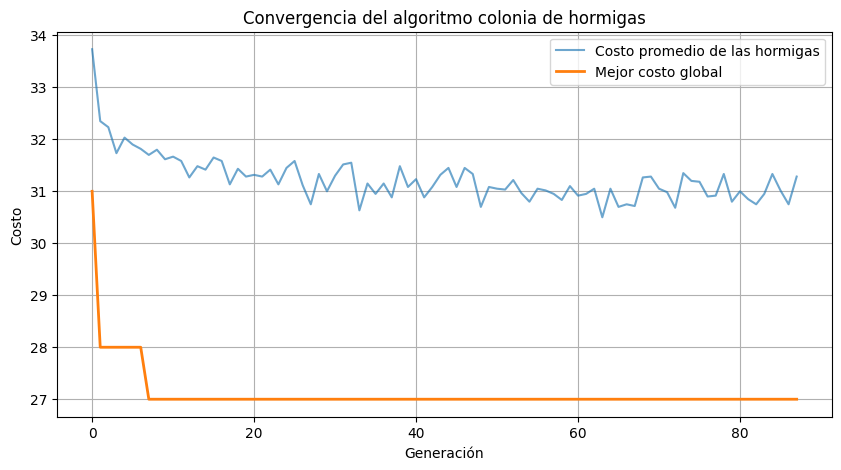

In [44]:
plt.figure(figsize=(10, 5))

plt.plot(
    resultado_aco["historial_promedio"],
    alpha=0.65,
    label="Costo promedio de las hormigas"
)

plt.plot(
    resultado_aco["historial_mejor"],
    linewidth=2,
    label="Mejor costo global"
)

plt.xlabel("Generación")
plt.ylabel("Costo")
plt.title("Convergencia del algoritmo colonia de hormigas")
plt.grid(True)
plt.legend()
plt.show()

El gráfico permite observar dos comportamientos. El costo promedio refleja la calidad general de las soluciones construidas por la colonia, mientras que el mejor costo global se mantiene o disminuye a medida que avanzan las generaciones. Cuando la curva del mejor costo permanece estable durante muchas generaciones, el algoritmo puede haber convergido o encontrarse estancado alrededor de una buena solución. El criterio de paciencia detiene la ejecución cuando no se detectan mejoras durante el número establecido de generaciones.

Las preguntas del 1 al 7 fueron respondidas en las partes generales del notebook. A continuación se contestan las preguntas específicas relacionadas con la aplicación de colonia de hormigas.

### Pregunta 8 (*)

**Diseña un algoritmo que mejore la complejidad del algoritmo por fuerza bruta. Argumenta por qué mejora al algoritmo por fuerza bruta.**

Se diseñó un algoritmo de colonia de hormigas adaptado al problema de organización de sesiones de doblaje. Cada hormiga construye una permutación válida de las tomas y las agrupa automáticamente en bloques de seis. La decisión de incorporar una toma depende de la feromona acumulada entre las tomas y del número de actores nuevos que esa toma añadiría al día actual.

El algoritmo mejora el enfoque de fuerza bruta porque no enumera las $n!$ permutaciones. Explora únicamente $H\cdot G$ soluciones completas, donde $H$ es el número de hormigas y $G$ el número de generaciones. Además, la búsqueda no es completamente aleatoria: las feromonas reutilizan la información obtenida de las mejores planificaciones y la heurística favorece agrupaciones de tomas que comparten actores. Por ello, se concentra el esfuerzo computacional en regiones prometedoras del espacio de soluciones.

La mejora es principalmente práctica y asintótica respecto del crecimiento factorial. No obstante, al ser una metaheurística, ACO no garantiza encontrar el óptimo global en todas las ejecuciones.

### Pregunta 9 (*)

**Calcula la complejidad del algoritmo.**

Sea:

- $G$: número de generaciones.
- $H$: número de hormigas por generación.
- $n$: número de tomas.
- $m$: número de actores.
- $k$: máximo de tomas por día, que en este problema es 6.

Para construir una solución, una hormiga realiza $n$ selecciones. En cada selección puede evaluar hasta $n$ candidatas y, para calcular el costo incremental, compara la participación de hasta $m$ actores. Por tanto, la construcción tiene un costo máximo de:

$$O(n^2m)$$

La evaluación final de una solución cuesta $O(nm)$. El depósito de feromonas revisa las parejas de tomas de cada día, con un costo $O(nk)$; como $k=6$ es constante, este término es lineal en $n$ y queda dominado por la construcción.

La complejidad temporal total es:

$$\boxed{O(GHn^2m)}$$

La matriz de feromonas requiere $O(n^2)$ memoria y la matriz de participación requiere $O(nm)$. Por tanto, la complejidad espacial es:

$$\boxed{O(n^2+nm)}$$

Aunque la complejidad es polinómica para valores fijados de $G$ y $H$, el método sigue siendo aproximado y su calidad depende de la configuración de parámetros.

### Pregunta 10

**Según el problema, diseña un juego de datos de entrada aleatorio.**

Se reutiliza el conjunto sintético generado previamente en el notebook. Se trata de una matriz binaria de 30 tomas por 10 actores, donde cada posición indica si un actor participa en una toma. La generación garantiza que cada toma incluya al menos un actor y que cada actor participe en al menos una toma. De esta forma, el conjunto aleatorio conserva la estructura y las restricciones esenciales del problema original.

In [45]:
print("Dimensiones de la matriz aleatoria:", A_ALEATORIA.shape)
print("Número de tomas:", A_ALEATORIA.shape[0])
print("Número de actores:", A_ALEATORIA.shape[1])
display(df_aleatorio.head())

Dimensiones de la matriz aleatoria: (30, 10)
Número de tomas: 30
Número de actores: 10


,Toma,1,2,3,4,5,6,7,8,9,10
0,1,0,0,0,0,1,0,0,0,1,0
1,2,0,0,0,0,0,1,0,1,0,0
2,3,0,0,0,0,0,1,0,1,1,0
3,4,0,0,0,0,0,1,1,0,1,0
4,5,0,0,0,0,0,0,0,1,0,1


### Pregunta 11

**Aplica el algoritmo al juego de datos aleatorio generado.**

A continuación se aplica el mismo algoritmo ACO al conjunto sintético. Se mantienen los parámetros principales para que el comportamiento sea comparable con la ejecución realizada sobre los datos originales.

In [46]:
inicio = time.perf_counter()

resultado_aco_aleatorio = colonia_hormigas(
    matriz=A_ALEATORIA,
    tomas_por_dia=6,
    num_hormigas=NUM_HORMIGAS,
    generaciones=GENERACIONES_ACO,
    alpha=ALPHA_ACO,
    beta=BETA_ACO,
    rho=RHO_ACO,
    q=Q_ACO,
    refuerzo_elitista=REFUERZO_ELITISTA,
    paciencia=PACIENCIA_ACO,
    semilla=SEMILLA_ACO
)

tiempo_aco_aleatorio = time.perf_counter() - inicio

print("ACO aplicado a datos aleatorios")
print("--------------------------------")
print(
    "Mejor costo encontrado:",
    resultado_aco_aleatorio["mejor_costo"]
)
print(
    "Mejor solución:",
    [
        toma + 1
        for toma in resultado_aco_aleatorio["mejor_solucion"]
    ]
)
print(
    "Generaciones ejecutadas:",
    resultado_aco_aleatorio["generaciones_ejecutadas"]
)
print(
    f"Tiempo de ejecución: {tiempo_aco_aleatorio:.4f} segundos"
)

ACO aplicado a datos aleatorios
--------------------------------
Mejor costo encontrado: 33
Mejor solución: [30, 1, 12, 3, 9, 26, 25, 11, 7, 16, 22, 13, 19, 5, 15, 2, 14, 24, 8, 23, 21, 27, 4, 10, 28, 17, 29, 6, 18, 20]
Generaciones ejecutadas: 98
Tiempo de ejecución: 42.9779 segundos


In [47]:
mostrar_planificacion_con_matriz(
    resultado_aco_aleatorio["mejor_solucion"],
    A_ALEATORIA,
    tomas_por_dia=6
)


Día 1
Tomas: [30, 1, 12, 3, 9, 26]
Actores: [2, 4, 5, 6, 8, 9]
Costo del día: 6

Día 2
Tomas: [25, 11, 7, 16, 22, 13]
Actores: [3, 5, 7, 8, 9]
Costo del día: 5

Día 3
Tomas: [19, 5, 15, 2, 14, 24]
Actores: [1, 6, 8, 9, 10]
Costo del día: 5

Día 4
Tomas: [8, 23, 21, 27, 4, 10]
Actores: [1, 4, 5, 6, 7, 8, 9, 10]
Costo del día: 8

Día 5
Tomas: [28, 17, 29, 6, 18, 20]
Actores: [1, 2, 3, 4, 5, 6, 7, 9, 10]
Costo del día: 9

Costo total: 33


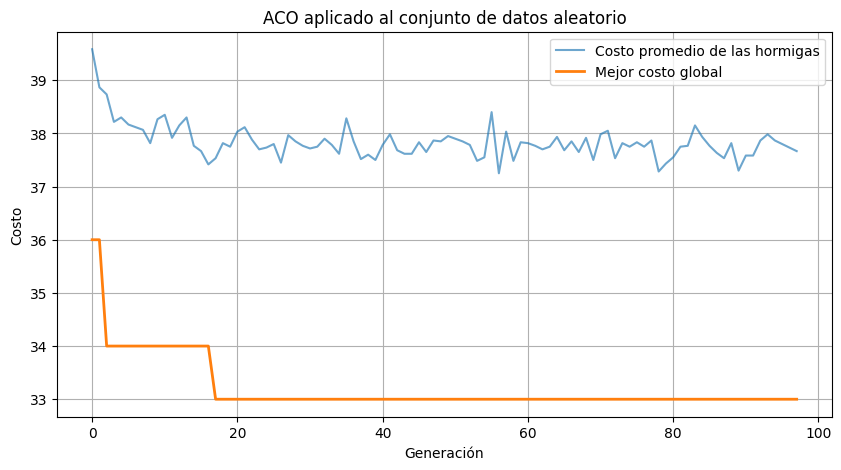

In [48]:
plt.figure(figsize=(10, 5))

plt.plot(
    resultado_aco_aleatorio["historial_promedio"],
    alpha=0.65,
    label="Costo promedio de las hormigas"
)

plt.plot(
    resultado_aco_aleatorio["historial_mejor"],
    linewidth=2,
    label="Mejor costo global"
)

plt.xlabel("Generación")
plt.ylabel("Costo")
plt.title("ACO aplicado al conjunto de datos aleatorio")
plt.grid(True)
plt.legend()
plt.show()

El algoritmo genera una planificación válida sobre los datos sintéticos y conserva la mejor solución encontrada durante el proceso. El resultado concreto puede variar al modificar la semilla, el número de hormigas, las generaciones o los parámetros de influencia de feromona y heurística. La ejecución con semilla fija permite reproducir el experimento.

### Pregunta 12

Las referencias empleadas se enumeran en la sección referencias.

### Pregunta 13

El estudio puede ampliarse mediante experimentos sistemáticos con los parámetros $\alpha$, $\beta$, $\rho$, el número de hormigas y el número de generaciones. También sería conveniente ejecutar varias semillas y comparar media, desviación estándar y mejor costo con los resultados de búsqueda aleatoria, recocido simulado y algoritmo genético.

Para instancias mayores podrían incorporarse listas de candidatos, reinicios de feromonas ante estancamiento, búsqueda local sobre la mejor hormiga y estrategias híbridas ACO–recocido simulado. El modelo también puede extenderse considerando duraciones diferentes de las tomas, disponibilidad diaria de actores, costos individuales, límites variables de grabación y restricciones de precedencia. Finalmente, una formulación de programación entera permitiría obtener un óptimo o una cota de referencia para evaluar con mayor precisión la calidad de las soluciones metaheurísticas.

$\Large \mathbf{5.\ Estrategia\ Búsqueda\ Local}$

**Descripción del método**

La búsqueda local [11] parte de una planificación válida y explora soluciones cercanas, denominadas **vecinos**, con el objetivo de reducir progresivamente el costo. En este problema una solución continúa representándose mediante una permutación de las 30 tomas, donde cada bloque consecutivo de seis posiciones corresponde a un día de grabación.

El orden interno de las tomas dentro de un mismo día no modifica la función objetivo. Por esta razón, intercambiar dos tomas del mismo día no genera una planificación realmente diferente. El vecindario utilizado intercambia una toma de un día con una toma de otro día. Así se mantiene automáticamente la restricción de seis tomas por día y se modifican únicamente los costos de los dos días afectados.

Se aplica una estrategia de **mejor mejora**: en cada iteración se examinan todos los intercambios válidos y se selecciona el que produce la mayor reducción del costo. El procedimiento termina cuando ningún vecino mejora la solución actual o cuando se alcanza el máximo de iteraciones. Para reducir la dependencia de la solución inicial se incorporan varios reinicios aleatorios.

**Funciones auxiliares y generación del vecindario**

Para evaluar un intercambio no es necesario volver a calcular el costo completo de los cinco días. Como el movimiento afecta solamente a dos días, se recalculan únicamente esos dos bloques. Esta evaluación incremental hace que la búsqueda sea más eficiente.

In [49]:
def costo_bloque_dia(tomas_dia, matriz):
    """Calcula el número de actores convocados en un día."""
    actores_presentes = np.any(
        matriz[list(tomas_dia), :] == 1,
        axis=0
    )
    return int(np.sum(actores_presentes))


def mejor_intercambio_entre_dias(
    solucion,
    matriz,
    tomas_por_dia=6
):
    """
    Busca el mejor vecino obtenido al intercambiar dos tomas
    pertenecientes a días diferentes.

    Devuelve:
    - posiciones del mejor intercambio;
    - variación del costo;
    - nuevo costo de los dos días afectados.
    """
    num_tomas = len(solucion)
    num_dias = num_tomas // tomas_por_dia

    costos_dia = []

    for dia in range(num_dias):
        inicio = dia * tomas_por_dia
        fin = inicio + tomas_por_dia
        costos_dia.append(
            costo_bloque_dia(
                solucion[inicio:fin],
                matriz
            )
        )

    mejor_movimiento = None
    mejor_delta = 0

    for dia_1 in range(num_dias - 1):
        inicio_1 = dia_1 * tomas_por_dia
        fin_1 = inicio_1 + tomas_por_dia

        for dia_2 in range(dia_1 + 1, num_dias):
            inicio_2 = dia_2 * tomas_por_dia
            fin_2 = inicio_2 + tomas_por_dia

            bloque_1_original = solucion[inicio_1:fin_1]
            bloque_2_original = solucion[inicio_2:fin_2]

            costo_anterior = (
                costos_dia[dia_1]
                + costos_dia[dia_2]
            )

            for pos_1 in range(inicio_1, fin_1):
                for pos_2 in range(inicio_2, fin_2):
                    bloque_1 = bloque_1_original.copy()
                    bloque_2 = bloque_2_original.copy()

                    indice_1 = pos_1 - inicio_1
                    indice_2 = pos_2 - inicio_2

                    bloque_1[indice_1], bloque_2[indice_2] = (
                        bloque_2[indice_2],
                        bloque_1[indice_1]
                    )

                    costo_nuevo_1 = costo_bloque_dia(
                        bloque_1,
                        matriz
                    )
                    costo_nuevo_2 = costo_bloque_dia(
                        bloque_2,
                        matriz
                    )

                    delta = (
                        costo_nuevo_1
                        + costo_nuevo_2
                        - costo_anterior
                    )

                    if delta < mejor_delta:
                        mejor_delta = delta
                        mejor_movimiento = {
                            "pos_1": pos_1,
                            "pos_2": pos_2,
                            "dia_1": dia_1,
                            "dia_2": dia_2,
                            "costo_nuevo_1": costo_nuevo_1,
                            "costo_nuevo_2": costo_nuevo_2,
                        }

    return mejor_movimiento, mejor_delta, costos_dia


**Algoritmo de búsqueda local**

La función siguiente ejecuta una búsqueda local [11] desde una solución inicial. Además, se implementa una versión multiarranque que repite el proceso desde diferentes permutaciones aleatorias y conserva la mejor planificación obtenida.

In [50]:
def busqueda_local_desde_solucion(
    solucion_inicial,
    matriz,
    tomas_por_dia=6,
    max_iteraciones=100
):
    """Ejecuta búsqueda local de mejor mejora desde una solución inicial."""
    solucion_actual = solucion_inicial.copy()

    costo_actual = calcular_costo_con_matriz(
        solucion_actual,
        matriz,
        tomas_por_dia
    )

    historial = [costo_actual]
    iteraciones = 0

    while iteraciones < max_iteraciones:
        movimiento, delta, _ = mejor_intercambio_entre_dias(
            solucion_actual,
            matriz,
            tomas_por_dia
        )

        if movimiento is None or delta >= 0:
            break

        pos_1 = movimiento["pos_1"]
        pos_2 = movimiento["pos_2"]

        solucion_actual[pos_1], solucion_actual[pos_2] = (
            solucion_actual[pos_2],
            solucion_actual[pos_1]
        )

        costo_actual += delta
        historial.append(costo_actual)
        iteraciones += 1

    return {
        "mejor_solucion": solucion_actual,
        "mejor_costo": costo_actual,
        "historial": historial,
        "iteraciones": iteraciones,
    }


def busqueda_local_multiarranque(
    matriz,
    tomas_por_dia=6,
    reinicios=20,
    max_iteraciones=100,
    semilla=None
):
    """Ejecuta búsqueda local desde varias soluciones iniciales aleatorias."""
    if reinicios <= 0:
        raise ValueError("El número de reinicios debe ser positivo.")

    if max_iteraciones <= 0:
        raise ValueError(
            "El número máximo de iteraciones debe ser positivo."
        )

    num_tomas = matriz.shape[0]

    if num_tomas % tomas_por_dia != 0:
        raise ValueError(
            "El número de tomas debe ser divisible por tomas_por_dia."
        )

    rng = random.Random(semilla)

    mejor_solucion_global = None
    mejor_costo_global = float("inf")
    mejor_historial_local = []
    costos_finales = []
    historial_mejor_global = []
    iteraciones_totales = 0

    for _ in range(reinicios):
        solucion_inicial = list(range(num_tomas))
        rng.shuffle(solucion_inicial)

        resultado = busqueda_local_desde_solucion(
            solucion_inicial=solucion_inicial,
            matriz=matriz,
            tomas_por_dia=tomas_por_dia,
            max_iteraciones=max_iteraciones
        )

        costo_final = resultado["mejor_costo"]
        costos_finales.append(costo_final)
        iteraciones_totales += resultado["iteraciones"]

        if costo_final < mejor_costo_global:
            mejor_costo_global = costo_final
            mejor_solucion_global = (
                resultado["mejor_solucion"].copy()
            )
            mejor_historial_local = resultado[
                "historial"
            ].copy()

        historial_mejor_global.append(
            mejor_costo_global
        )

    return {
        "mejor_solucion": mejor_solucion_global,
        "mejor_costo": mejor_costo_global,
        "costos_finales": costos_finales,
        "historial_mejor_global": historial_mejor_global,
        "mejor_historial_local": mejor_historial_local,
        "iteraciones_totales": iteraciones_totales,
        "reinicios": reinicios,
    }


**Ejecución sobre el problema original**

In [51]:
REINICIOS_BL = 20
MAX_ITERACIONES_BL = 100
SEMILLA_BL = 42

inicio = time.perf_counter()

resultado_bl = busqueda_local_multiarranque(
    matriz=A,
    tomas_por_dia=TOMAS_POR_DIA,
    reinicios=REINICIOS_BL,
    max_iteraciones=MAX_ITERACIONES_BL,
    semilla=SEMILLA_BL
)

tiempo_bl = time.perf_counter() - inicio

mejor_solucion_bl = resultado_bl["mejor_solucion"]
mejor_costo_bl = resultado_bl["mejor_costo"]

print("Búsqueda local multiarranque")
print("----------------------------")
print("Mejor costo encontrado:", mejor_costo_bl)
print(
    "Mejor solución:",
    [toma + 1 for toma in mejor_solucion_bl]
)
print("Reinicios ejecutados:", resultado_bl["reinicios"])
print(
    "Iteraciones locales totales:",
    resultado_bl["iteraciones_totales"]
)
print(f"Tiempo de ejecución: {tiempo_bl:.4f} segundos")


Búsqueda local multiarranque
----------------------------
Mejor costo encontrado: 28
Mejor solución: [23, 24, 19, 18, 17, 14, 12, 8, 26, 20, 10, 1, 15, 2, 11, 3, 4, 22, 7, 5, 29, 30, 21, 28, 6, 25, 13, 27, 9, 16]
Reinicios ejecutados: 20
Iteraciones locales totales: 104
Tiempo de ejecución: 1.6287 segundos


**Planificación obtenida**

In [52]:
mostrar_planificacion(mejor_solucion_bl)



Día 1
Tomas: [23, 24, 19, 18, 17, 14]
Actores: [1, 3, 6]
Costo del día: 3

Día 2
Tomas: [12, 8, 26, 20, 10, 1]
Actores: [1, 2, 3, 4, 5, 6, 9]
Costo del día: 7

Día 3
Tomas: [15, 2, 11, 3, 4, 22]
Actores: [1, 2, 3, 4, 5, 7, 8]
Costo del día: 7

Día 4
Tomas: [7, 5, 29, 30, 21, 28]
Actores: [1, 2, 4, 5, 6, 8]
Costo del día: 6

Día 5
Tomas: [6, 25, 13, 27, 9, 16]
Actores: [1, 2, 4, 5, 10]
Costo del día: 5

Costo total: 28


**Gráficos de evolución**

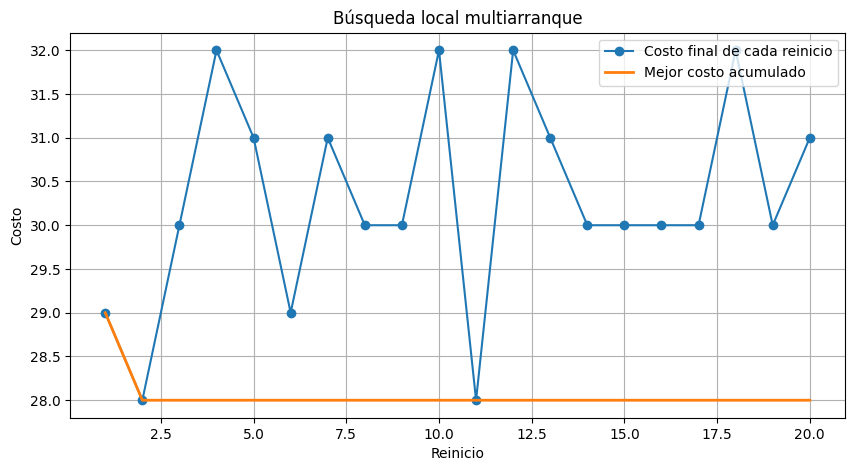

In [53]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, REINICIOS_BL + 1),
    resultado_bl["costos_finales"],
    marker="o",
    label="Costo final de cada reinicio"
)

plt.plot(
    range(1, REINICIOS_BL + 1),
    resultado_bl["historial_mejor_global"],
    linewidth=2,
    label="Mejor costo acumulado"
)

plt.xlabel("Reinicio")
plt.ylabel("Costo")
plt.title("Búsqueda local multiarranque")
plt.grid(True)
plt.legend()
plt.show()


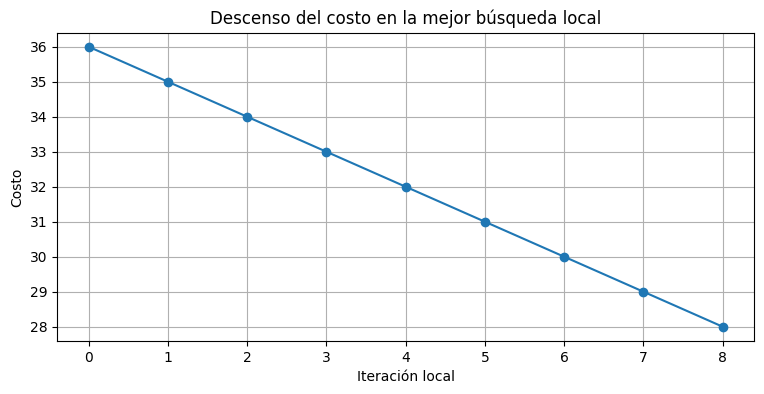

In [54]:
plt.figure(figsize=(9, 4))

plt.plot(
    resultado_bl["mejor_historial_local"],
    marker="o"
)

plt.xlabel("Iteración local")
plt.ylabel("Costo")
plt.title(
    "Descenso del costo en la mejor búsqueda local"
)
plt.grid(True)
plt.show()


El primer gráfico compara el mínimo local obtenido en cada reinicio y muestra cómo evoluciona el mejor costo global. El segundo representa la secuencia de mejoras de la mejor ejecución local. Debido a que solo se aceptan movimientos que reducen estrictamente el costo, esta última curva es monótona no creciente. La ejecución se detiene cuando ningún intercambio entre días produce una mejora.

Las preguntas del 1 al 7 fueron contestadas en las partes generales del notebook (Parte I a Parte III). A continuación se responden las preguntas específicas relacionadas con la estrategia de búsqueda local.

### Pregunta 8 (*)

**Diseña un algoritmo que mejore la complejidad del algoritmo por fuerza bruta. Argumenta por qué mejora al algoritmo por fuerza bruta.**

Se diseñó un algoritmo de búsqueda local basado en intercambios de tomas entre días diferentes. El procedimiento parte de una planificación válida, examina su vecindario y aplica el intercambio que produce la mayor reducción del número total de asistencias actor-día. El proceso se repite hasta que no existe una mejora o se alcanza un máximo de iteraciones.

La restricción de seis tomas por día se conserva automáticamente porque cada movimiento intercambia dos tomas, en lugar de insertar o eliminar elementos. Además, no se consideran intercambios dentro de un mismo día, pues estos no cambian la agrupación ni el costo.

Este algoritmo mejora el enfoque de fuerza bruta porque no enumera las $n!$ permutaciones posibles. En cada iteración analiza solamente un vecindario de tamaño cuadrático y avanza hacia una solución mejor. Los reinicios aleatorios permiten explorar diferentes regiones del espacio sin llegar al crecimiento factorial. La búsqueda local no garantiza encontrar el óptimo global, ya que puede detenerse en un mínimo local, pero permite obtener buenas soluciones en un tiempo razonable.

### Pregunta 9 (*)

**Calcula la complejidad del algoritmo.**

Sea:

- $R$: número de reinicios.
- $I$: máximo de iteraciones de mejora por reinicio.
- $n$: número de tomas.
- $m$: número de actores.
- $k$: número de tomas por día, que en este problema es 6.

El vecindario considera intercambios entre posiciones pertenecientes a días diferentes. Su tamaño es del orden de $O(n^2)$. Para evaluar cada intercambio solo se recalculan los dos días afectados. El costo de recalcular un día es $O(km)$, por lo que evaluar todo el vecindario cuesta:

$$O(n^2km)$$

Al realizar como máximo $I$ iteraciones en cada uno de los $R$ reinicios, la complejidad temporal total es:

$$\boxed{O(RIn^2km)}$$

Como $k=6$ es constante, puede simplificarse a:

$$\boxed{O(RIn^2m)}$$

La solución y los costos diarios requieren memoria lineal respecto al número de tomas y actores. Como los vecinos se evalúan de uno en uno y no se almacenan todos simultáneamente, la complejidad espacial adicional es aproximadamente:

$$\boxed{O(n+km)}$$

Esta complejidad es polinómica para valores fijados de $R$ e $I$, frente al crecimiento factorial de la fuerza bruta.

### Pregunta 10

**Según el problema, diseña un juego de datos de entrada aleatorio.**

Se reutiliza el conjunto sintético generado previamente en el notebook. Está formado por una matriz binaria de 30 tomas y 10 actores, con una probabilidad de participación del 30 %. La generación garantiza que cada toma tenga al menos un actor y que todos los actores participen en alguna toma. Por tanto, conserva la estructura y las restricciones principales del problema original.

In [55]:
print("Dimensiones de la matriz aleatoria:", A_ALEATORIA.shape)
print("Número de tomas:", A_ALEATORIA.shape[0])
print("Número de actores:", A_ALEATORIA.shape[1])
display(df_aleatorio.head())


Dimensiones de la matriz aleatoria: (30, 10)
Número de tomas: 30
Número de actores: 10


,Toma,1,2,3,4,5,6,7,8,9,10
0,1,0,0,0,0,1,0,0,0,1,0
1,2,0,0,0,0,0,1,0,1,0,0
2,3,0,0,0,0,0,1,0,1,1,0
3,4,0,0,0,0,0,1,1,0,1,0
4,5,0,0,0,0,0,0,0,1,0,1


### Pregunta 11

**Aplica el algoritmo al juego de datos aleatorio generado.**

A continuación se ejecuta la misma búsqueda local multiarranque sobre la matriz sintética. Se conservan los parámetros principales para facilitar la comparación con el problema original.

In [56]:
inicio = time.perf_counter()

resultado_bl_aleatorio = busqueda_local_multiarranque(
    matriz=A_ALEATORIA,
    tomas_por_dia=6,
    reinicios=REINICIOS_BL,
    max_iteraciones=MAX_ITERACIONES_BL,
    semilla=SEMILLA_BL
)

tiempo_bl_aleatorio = time.perf_counter() - inicio

print("Búsqueda local aplicada a datos aleatorios")
print("------------------------------------------")
print(
    "Mejor costo encontrado:",
    resultado_bl_aleatorio["mejor_costo"]
)
print(
    "Mejor solución:",
    [
        toma + 1
        for toma in resultado_bl_aleatorio["mejor_solucion"]
    ]
)
print(
    "Iteraciones locales totales:",
    resultado_bl_aleatorio["iteraciones_totales"]
)
print(
    f"Tiempo de ejecución: "
    f"{tiempo_bl_aleatorio:.4f} segundos"
)


Búsqueda local aplicada a datos aleatorios
------------------------------------------
Mejor costo encontrado: 34
Mejor solución: [11, 13, 25, 22, 1, 16, 12, 17, 28, 30, 20, 18, 14, 6, 24, 15, 4, 29, 27, 10, 8, 21, 3, 23, 7, 19, 9, 26, 2, 5]
Iteraciones locales totales: 115
Tiempo de ejecución: 1.7661 segundos


In [57]:
mostrar_planificacion_con_matriz(
    resultado_bl_aleatorio["mejor_solucion"],
    A_ALEATORIA,
    tomas_por_dia=6
)



Día 1
Tomas: [11, 13, 25, 22, 1, 16]
Actores: [3, 5, 7, 8, 9]
Costo del día: 5

Día 2
Tomas: [12, 17, 28, 30, 20, 18]
Actores: [1, 2, 3, 4, 5, 6, 9]
Costo del día: 7

Día 3
Tomas: [14, 6, 24, 15, 4, 29]
Actores: [1, 2, 3, 4, 6, 7, 9, 10]
Costo del día: 8

Día 4
Tomas: [27, 10, 8, 21, 3, 23]
Actores: [1, 4, 5, 6, 7, 8, 9, 10]
Costo del día: 8

Día 5
Tomas: [7, 19, 9, 26, 2, 5]
Actores: [4, 5, 6, 8, 9, 10]
Costo del día: 6

Costo total: 34


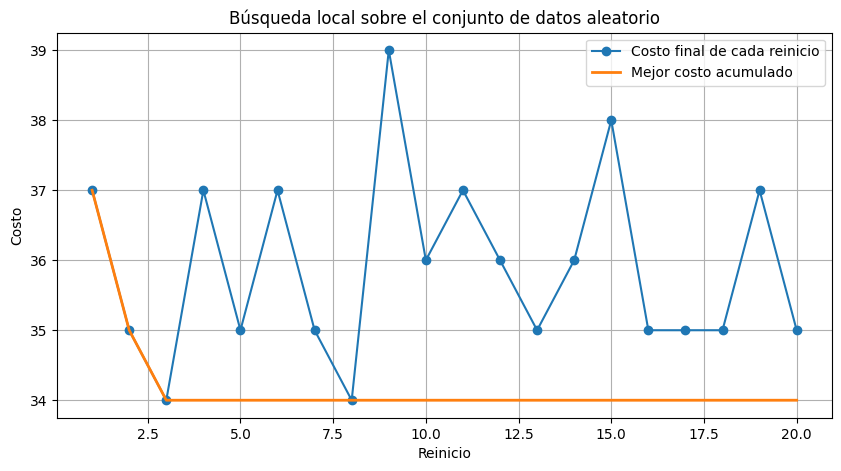

In [58]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, REINICIOS_BL + 1),
    resultado_bl_aleatorio["costos_finales"],
    marker="o",
    label="Costo final de cada reinicio"
)

plt.plot(
    range(1, REINICIOS_BL + 1),
    resultado_bl_aleatorio["historial_mejor_global"],
    linewidth=2,
    label="Mejor costo acumulado"
)

plt.xlabel("Reinicio")
plt.ylabel("Costo")
plt.title(
    "Búsqueda local sobre el conjunto de datos aleatorio"
)
plt.grid(True)
plt.legend()
plt.show()


La búsqueda local [11] produce una planificación válida para el conjunto sintético y conserva el mejor mínimo local obtenido entre todos los reinicios. El resultado concreto depende de la matriz generada, de las soluciones iniciales y de la semilla. Utilizar una semilla fija permite reproducir el experimento y comparar sus resultados con las demás estrategias del notebook.

### Pregunta 12

Las referencias utilizadas se enumeran en la sección final del notebook.

### Pregunta 13

El estudio puede ampliarse incorporando vecindarios adicionales, por ejemplo intercambiar varias tomas simultáneamente, mover bloques completos o aplicar operadores de tipo 2-opt adaptados a la agrupación por días. Una búsqueda de vecindad variable permitiría cambiar de operador cuando el algoritmo se estanque.

También pueden realizarse más reinicios, comparar estrategias de primera mejora y mejor mejora, y analizar estadísticamente varias semillas mediante la media, desviación estándar y mejor costo. Otra posibilidad es hibridar la búsqueda local con el algoritmo genético, ACO o recocido simulado, utilizando la búsqueda local para refinar las mejores soluciones obtenidas por esas metaheurísticas.

Para instancias mayores sería conveniente mantener la evaluación incremental, utilizar listas de movimientos candidatos y actualizar únicamente los costos de los días afectados. El modelo podría extenderse incorporando duraciones diferentes de las tomas, disponibilidad diaria de actores, costos individuales, límites variables por día y restricciones de precedencia.

## Comparación experimental de los cinco métodos

En esta sección se reúnen los resultados obtenidos por las cinco estrategias aplicadas al problema original. La comparación considera el **mejor costo encontrado**, el **tiempo de ejecución**, el número de iteraciones, generaciones o reinicios ejecutados y la semilla utilizada.

Como el objetivo del problema es minimizar el número total de asistencias actor-día, un costo menor representa una planificación mejor. Sin embargo, el tiempo y el número de iteraciones no son directamente equivalentes entre métodos, ya que cada estrategia realiza operaciones diferentes. Por ello, la tabla debe interpretarse como una comparación experimental bajo las configuraciones utilizadas para este trabajo.

In [59]:
# Construcción del cuadro comparativo experimental

datos_comparacion = [
    {
        "Método": "Búsqueda aleatoria",
        "Mejor costo": mejor_costo_aleatorio,
        "Tiempo (s)": tiempo_aleatorio,
        "Proceso ejecutado": f"{ITERACIONES} iteraciones",
        "Semilla": "Sin fijar" if SEMILLA is None else SEMILLA
    },
    {
        "Método": "Recocido simulado",
        "Mejor costo": mejor_costo_recocido,
        "Tiempo (s)": tiempo_recocido,
        "Proceso ejecutado": (
            f'{resultado_recocido["iteraciones"]} iteraciones'
        ),
        "Semilla": SEMILLA_RECOCIDO
    },
    {
        "Método": "Algoritmo genético",
        "Mejor costo": mejor_costo_genetico,
        "Tiempo (s)": tiempo_genetico,
        "Proceso ejecutado": (
            f'{resultado_genetico["generaciones_ejecutadas"]} generaciones'
        ),
        "Semilla": "Sin fijar"
    },
    {
        "Método": "Colonia de hormigas",
        "Mejor costo": mejor_costo_aco,
        "Tiempo (s)": tiempo_aco,
        "Proceso ejecutado": (
            f'{resultado_aco["generaciones_ejecutadas"]} generaciones'
        ),
        "Semilla": SEMILLA_ACO
    },
    {
        "Método": "Búsqueda local",
        "Mejor costo": mejor_costo_bl,
        "Tiempo (s)": tiempo_bl,
        "Proceso ejecutado": (
            f'{resultado_bl["reinicios"]} reinicios / '
            f'{resultado_bl["iteraciones_totales"]} mejoras'
        ),
        "Semilla": SEMILLA_BL
    }
]

df_comparacion = pd.DataFrame(datos_comparacion)

# Mejora porcentual con respecto a la búsqueda aleatoria.
costo_referencia = float(mejor_costo_aleatorio)

df_comparacion["Mejora frente a aleatoria (%)"] = (
    100
    * (costo_referencia - df_comparacion["Mejor costo"])
    / costo_referencia
).round(2)

# Redondeo para facilitar la presentación.
df_comparacion["Tiempo (s)"] = (
    df_comparacion["Tiempo (s)"].astype(float).round(4)
)

# Posición según el costo: 1 corresponde al mejor resultado.
df_comparacion["Posición por costo"] = (
    df_comparacion["Mejor costo"]
    .rank(method="min", ascending=True)
    .astype(int)
)

df_comparacion = df_comparacion[
    [
        "Método",
        "Mejor costo",
        "Tiempo (s)",
        "Proceso ejecutado",
        "Semilla",
        "Mejora frente a aleatoria (%)",
        "Posición por costo"
    ]
].sort_values(
    by=["Posición por costo", "Tiempo (s)"],
    ascending=[True, True]
).reset_index(drop=True)

df_comparacion


,Método,Mejor costo,Tiempo (s),Proceso ejecutado,Semilla,Mejora frente a aleatoria (%),Posición por costo
0,Algoritmo genético,27,7.5428,236 generaciones,Sin fijar,15.62,1
1,Recocido simulado,27,13.2028,229700 iteraciones,42,15.62,1
2,Colonia de hormigas,27,41.9494,88 generaciones,42,15.62,1
3,Búsqueda local,28,1.6287,20 reinicios / 104 mejoras,42,12.50,4
4,Búsqueda aleatoria,32,0.8913,10000 iteraciones,Sin fijar,0.00,5


### Identificación automática del mejor resultado

La siguiente celda identifica el método que obtuvo el menor costo y el método que necesitó menos tiempo. Esta distinción es importante porque el algoritmo con mejor solución no necesariamente es el más rápido.

In [60]:
fila_mejor_costo = df_comparacion.loc[
    df_comparacion["Mejor costo"].idxmin()
]

fila_menor_tiempo = df_comparacion.loc[
    df_comparacion["Tiempo (s)"].idxmin()
]

print(
    "Mejor resultado por costo:",
    fila_mejor_costo["Método"],
    "con costo",
    fila_mejor_costo["Mejor costo"]
)

print(
    "Menor tiempo de ejecución:",
    fila_menor_tiempo["Método"],
    "con",
    f'{fila_menor_tiempo["Tiempo (s)"]:.4f}',
    "segundos"
)

empates_mejor_costo = df_comparacion[
    df_comparacion["Mejor costo"]
    == df_comparacion["Mejor costo"].min()
]["Método"].tolist()

if len(empates_mejor_costo) > 1:
    print(
        "Métodos empatados con el mejor costo:",
        ", ".join(empates_mejor_costo)
    )


Mejor resultado por costo: Algoritmo genético con costo 27
Menor tiempo de ejecución: Búsqueda aleatoria con 0.8913 segundos
Métodos empatados con el mejor costo: Algoritmo genético, Recocido simulado, Colonia de hormigas


### Comparación gráfica del mejor costo

En este gráfico una barra [17] más baja indica una mejor solución, porque el problema es de minimización.

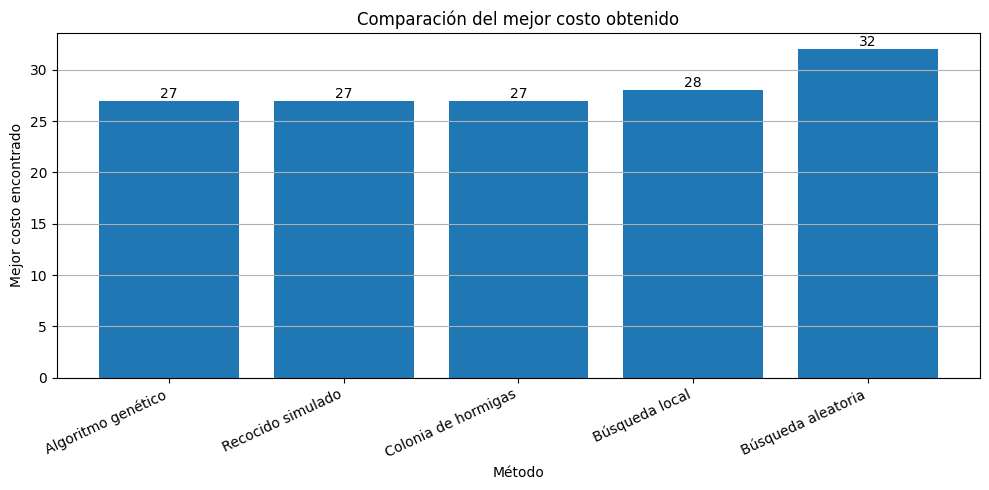

In [62]:
df_grafico_costo = df_comparacion.sort_values(
    by="Mejor costo",
    ascending=True
)

plt.figure(figsize=(10, 5))

barras = plt.bar(
    df_grafico_costo["Método"],
    df_grafico_costo["Mejor costo"]
)

plt.xlabel("Método")
plt.ylabel("Mejor costo encontrado")
plt.title("Comparación del mejor costo obtenido")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y")

for barra, valor in zip(
    barras,
    df_grafico_costo["Mejor costo"]
):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height(),
        str(valor),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


### Comparación gráfica del tiempo de ejecución

Este gráfico [17] muestra el tiempo medido en una ejecución de cada método. Los valores pueden variar según el equipo, la carga del sistema, la semilla y los parámetros utilizados.

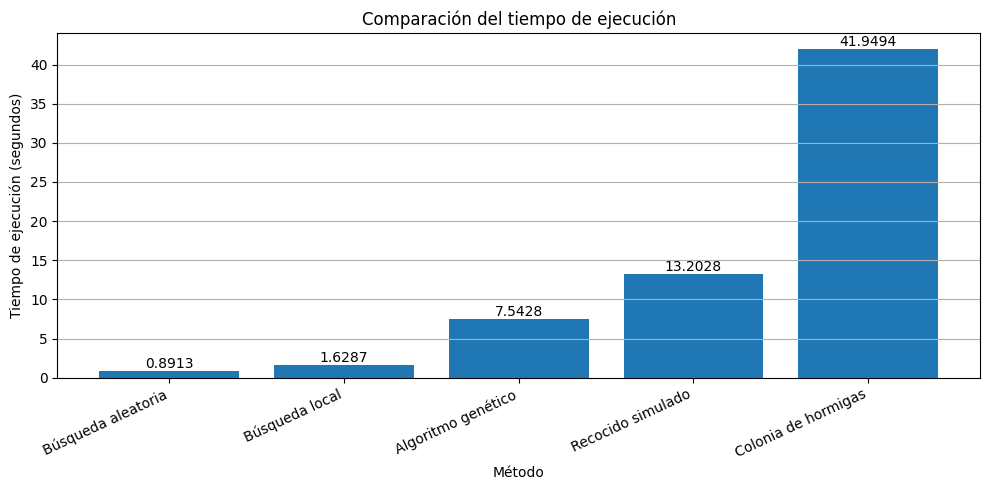

In [63]:
df_grafico_tiempo = df_comparacion.sort_values(
    by="Tiempo (s)",
    ascending=True
)

plt.figure(figsize=(10, 5))

barras = plt.bar(
    df_grafico_tiempo["Método"],
    df_grafico_tiempo["Tiempo (s)"]
)

plt.xlabel("Método")
plt.ylabel("Tiempo de ejecución (segundos)")
plt.title("Comparación del tiempo de ejecución")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y")

for barra, valor in zip(
    barras,
    df_grafico_tiempo["Tiempo (s)"]
):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height(),
        f"{valor:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


### Análisis del cuadro comparativo

El cuadro [17] permite comparar simultáneamente la calidad de la solución y el tiempo requerido. La búsqueda aleatoria constituye una referencia básica, pues genera soluciones sin utilizar aprendizaje ni información del proceso. El recocido simulado incorpora aceptación probabilística de empeoramientos, lo que le permite escapar de algunos mínimos locales. El algoritmo genético y la colonia de hormigas trabajan con varias soluciones en cada generación, por lo que realizan una exploración más amplia, aunque normalmente requieren un mayor costo computacional. La búsqueda local mejora de manera directa una planificación mediante intercambios entre días y suele converger rápidamente, pero puede detenerse en un mínimo local.

La conclusión experimental debe basarse en los valores producidos al ejecutar todas las celdas del notebook. El método más conveniente no tiene por qué ser únicamente el que obtiene el menor costo: también deben considerarse el tiempo de ejecución, la estabilidad entre distintas semillas y la facilidad para ajustar sus parámetros.

Para una comparación estadística más rigurosa sería recomendable ejecutar cada método varias veces con distintas semillas y presentar el costo mínimo, costo promedio, desviación estándar y tiempo promedio. En este notebook, la tabla resume una ejecución de cada estrategia con los parámetros establecidos en sus respectivas secciones.

## Conclusiones generales


La fuerza bruta permite comprobar el funcionamiento del modelo en una instancia reducida, pero su crecimiento factorial impide aplicarla al problema completo. La búsqueda aleatoria, el recocido simulado, el algoritmo genético, la colonia de hormigas y la búsqueda local reducen considerablemente el número de soluciones evaluadas y permiten trabajar con las 30 tomas.
Las cinco estrategias presentan mecanismos diferentes. La búsqueda aleatoria sirve como referencia básica; el recocido simulado acepta ocasionalmente empeoramientos para escapar de mínimos locales; el algoritmo genético combina una población de soluciones; ACO construye planificaciones mediante feromonas e información heurística; y la búsqueda local mejora de forma determinista una solución mediante intercambios entre días.

**La búsqueda aleatoria** constituyó la línea base para comparar el desempeño de las demás estrategias de optimización. Su implementación es sencilla y presenta el menor tiempo de ejecución (0,8913 s); sin embargo, al no utilizar información de las soluciones previamente evaluadas, su capacidad de exploración es limitada. Después de 10.000 iteraciones obtuvo un costo de 32, el peor entre todos los métodos analizados. Este resultado confirma que una exploración completamente aleatoria resulta insuficiente para un problema combinatorio de estas características, aunque proporciona una referencia útil para cuantificar la mejora alcanzada por las metaheurísticas.

**El recocido simulado** [14] obtuvo uno de los mejores resultados experimentales, alcanzando un costo de 27, equivalente al mejor valor encontrado durante el estudio. Su principal fortaleza radica en la aceptación controlada de soluciones temporalmente peores durante las primeras etapas de la búsqueda, lo que favorece el escape de mínimos locales y permite explorar regiones más amplias del espacio de soluciones. No obstante, esta capacidad exploratoria implica un elevado esfuerzo computacional, reflejado en las 229.700 iteraciones y un tiempo de ejecución de 13,20 segundos. En consecuencia, representa un equilibrio adecuado entre calidad de la solución y robustez frente a óptimos locales.

**El algoritmo genético** [9, 12] fue el método que presentó el mejor compromiso entre calidad de la solución y eficiencia computacional. Con únicamente 236 generaciones logró alcanzar el costo mínimo de 27, igualando al recocido simulado y a la colonia de hormigas, pero con un tiempo de ejecución considerablemente menor (7,54 segundos). La combinación de selección, cruce y mutación permitió mantener diversidad en la población y favorecer la evolución progresiva hacia soluciones de alta calidad. Estos resultados muestran que el algoritmo genético constituye una alternativa muy competitiva para este tipo de problemas de planificación combinatoria.

**La colonia de hormigas** [7-8] también alcanzó el costo mínimo de 27, demostrando la efectividad del aprendizaje colectivo basado en feromonas para construir planificaciones de buena calidad. La información acumulada durante el proceso permitió reforzar progresivamente las decisiones más prometedoras y orientar la exploración hacia regiones favorables del espacio de búsqueda. Sin embargo, este beneficio tuvo como contrapartida el mayor tiempo de ejecución del estudio (41,95 segundos), debido al costo de construir soluciones completas y actualizar la matriz de feromonas en cada generación. A pesar de ello, los resultados evidencian que ACO es una estrategia robusta cuando la prioridad es obtener soluciones de alta calidad antes que minimizar el tiempo de cálculo.

**La búsqueda local** [11] obtuvo un costo de 28, quedando muy próxima al mejor resultado alcanzado por las demás metaheurísticas. Su principal ventaja fue la rapidez de ejecución (1,63 segundos), ya que únicamente realiza intercambios locales entre tomas pertenecientes a distintos días y acepta exclusivamente movimientos que mejoran la solución. Esta estrategia permite converger rápidamente hacia un mínimo local, aunque precisamente esa característica constituye su principal limitación, pues puede impedir alcanzar el óptimo global. Los 20 reinicios implementados redujeron parcialmente este problema al explorar distintas soluciones iniciales, demostrando que la búsqueda local resulta especialmente adecuada como método de refinamiento o como componente de estrategias híbridas.



## Referencias

1. Aarts, E., y Lenstra, J. K. (Eds.). (2003). *Local search in combinatorial optimization*. Princeton University Press.

2. Camacho, José M. (2026). VC4 – Problemas del Trabajo Práctico: 03MIAR – Algoritmos de optimización [Archivo PDF]. Campus Virtual VIU.

3. Camacho, José M. (2026a). AG3 – Actividad Guiada 3. 03MIAR – Algoritmos de optimización [Archivo PDF]. Campus Virtual VIU. universidadviu.com

4. Camacho, José M. (2026b). VC6 – Algoritmos genéticos. 03MIAR – Algoritmos de optimización [Archivo PDF]. Universidad Internacional de Valencia.

5. Camacho, José M. (2026c). VC5 – Algoritmos Heurísticos. 03MIAR – Algoritmos de optimización [Archivo PDF]. Universidad Internacional de Valencia.

6. Camacho, José M. (2026d). AG3 – Actividad Guiada 3 (2ª parte). 03MIAR – Algoritmos de optimización [Archivo PDF]. Universidad Internacional de Valencia.

7. Dorigo, M., Maniezzo, V., y Colorni, A. (1996). Ant system: Optimization by a colony of cooperating agents. *IEEE Transactions on Systems, Man, and Cybernetics, Part B (Cybernetics)*, 26(1), 29–41. https://ieeexplore.ieee.org/document/484436

8. Dorigo, M., y Stützle, T. (2004). *Ant colony optimization*. MIT Press.

9. Goldberg, D. E. (1989). *Genetic algorithms in search, optimization, and machine learning*. Addison-Wesley.

10. Harris, C. R., Millman, K. J., van der Walt, S. J., et al. (2020). Array programming with NumPy. Nature, 585(7825), 357–362. https://doi.org/10.1038/s41586-020-2649-2

11. Hoos, H. H., y Stützle, T. (2004). *Stochastic local search: Foundations and applications*. Morgan Kaufmann.

12. Holland, J. H. (1975). *Adaptation in natural and artificial systems*. University of Michigan Press.

13. Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. Computing in Science & Engineering, 9(3), 90–95. https://doi.org/10.1109/MCSE.2007.55

14. Kirkpatrick, S., Gelatt, C. D., y Vecchi, M. P. (1983). Optimization by simulated annealing. *Science*, 220(4598), 671–680. https://www.science.org/doi/10.1126/science.220.4598.671

15. McKinney, W. (2022). Python for Data Analysis: Data Wrangling with pandas, NumPy, and Jupyter (3rd ed.). O'Reilly Media.

16. Python Software Foundation. (2025). Python Language Reference. https://www.python.org/

17. Tukey, J. W. (1977). Exploratory Data Analysis. Addison-Wesley.

### Declaración de uso de IA

Se ha utilizado herramienta de IA generativa para formatear la citación a formato APA, revisar bibliografía, revisar algunas ortografías, formatear formulas en Markdown, y como herramienta consultiva para revisar instrucciones y/o errores del uso de sintaxis para Python.

## Anexos

1. Sensibilidad de parámetros


| Método | Parámetros Analizados | ¿Cómo funciona? | ¿Para qué sirve el parámetro? |
| :--- | :--- | :--- | :--- |
| **Búsqueda aleatoria** | Número de iteraciones | Prueba soluciones al azar sin memoria. | Define cuántos intentos totales hará el algoritmo. |
| **Recocido simulado** | Temperatura inicial, factor de enfriamiento | Explora el espacio aceptando malas soluciones al inicio para no atascarse. | Controlan la probabilidad y velocidad de volverse más estricto. |
| **Algoritmo genético** | Tamaño de población, probabilidad de mutación, generaciones | Evoluciona un grupo de soluciones combinando las mejores y alterándolas. | Determinan la diversidad, la variedad de cambios y el tiempo de evolución. |
| **Colonia de hormigas** | $\alpha$, $\beta$, evaporación, número de hormigas | Agentes buscan rutas dejando un rastro químico que atrae a otros. | Balancéan el peso de la memoria química, el atractivo visual y el olvido. |
| **Búsqueda local** | Número de reinicios, máximo de iteraciones | Explora soluciones vecinas partiendo de un punto inicial. | Controlan cuántas veces salta a otra zona y cuántos pasos da ahí. |

Durante el desarrollo se realizaron pruebas variando los parámetros principales de cada algoritmo hasta obtener una configuración que equilibrara calidad de solución y tiempo de ejecución.

2. Análisis comparativo de las estrategias

| Aspecto | Aleatoria | Recocido | AG | ACO | Local |
| :--- | :--- | :--- | :--- | :--- | :--- |
| Exploración | Muy alta | Alta | Alta | Media-Alta | Baja |
| Explotación | Muy baja | Media | Alta | Alta | Muy alta |
| Escape de mínimos locales | No | Sí | Sí | Sí | No |
| Ajuste de parámetros | Bajo | Medio | Alto | Alto | Bajo |
| Facilidad de implementación | Muy alta | Alta | Media | Baja | Alta |

Desde un punto de vista metodológico, las cinco estrategias presentan comportamientos diferentes. La búsqueda aleatoria prioriza la exploración sin aprovechar la información obtenida durante la ejecución. La búsqueda local representa el extremo opuesto, ya que explota intensivamente una región del espacio de soluciones hasta alcanzar un mínimo local. El recocido simulado incorpora un mecanismo probabilístico que equilibra exploración y explotación mediante la aceptación temporal de soluciones peores. El algoritmo genético y la colonia de hormigas mantienen simultáneamente varias soluciones candidatas, favoreciendo una exploración más amplia del espacio de búsqueda y reduciendo la probabilidad de estancamiento prematuro.